<a href="https://colab.research.google.com/github/jonasknoll57/Bachelorarbeit_Demand-AD/blob/main/V16__V13_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# V13 -- Faire Evaluation, Per-Type PR-AUC & Isolation Forest Baseline

Aufbauend auf V12. Zentrale Aenderungen:

1. **Faire Synthetic Injection**: Zwei Szenarien -- "balanced" und "point_heavy"
2. **PR-AUC pro Anomalietyp**: Vollstaendige PR-AUC pro Typ (nicht nur Detection Rate)
3. **Isolation Forest Baseline**: Nicht-DL-Vergleichsmodell
4. **Stabile V12-Erkenntnisse uebernommen**: 9 Basisfeatures, Standard-Rekonstruktion, last_step_mean als Primaermetrik

### V12-Erkenntnisse (beibehalten):
- Feature-Set: `n_lends, n_returns, hour_sin/cos, dow_sin/cos, month_sin/cos, is_weekend`
- Reconstruction-Target: Standard (alle Input-Features)
- Wetter-Features: Kein Mehrwert → nicht verwenden
- Demand-only Target: Kein Mehrwert → nicht verwenden
- Zero-Shot mit Target-Scaler: Konsistent stark

In [1]:
# ══════════════════════════════════════════════════════════════
# 0a -- Colab Setup
# ══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ══════════════════════════════════════════════════════════════
# 0b -- Imports
# ══════════════════════════════════════════════════════════════
import os, math, json, random, warnings, time, re, glob, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass, field, asdict
from typing import List, Optional, Tuple, Dict
from copy import deepcopy
from collections import defaultdict

from scipy.stats import poisson
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TF: {tf.__version__}, GPU: {tf.config.list_physical_devices('GPU')}")

TF: 2.19.0, GPU: []


In [3]:
# ══════════════════════════════════════════════════════════════
# 0c -- Config + Pfade
# ══════════════════════════════════════════════════════════════
DATA_BASE    = '/content/drive/MyDrive/BA_Colab/data'
CLEANED_BASE = '/content/drive/MyDrive/BA_Colab/cleaned'

RUN_NAME    = 'v16__v13.2'
RESULTS_DIR = f'{DATA_BASE}/{RUN_NAME}'
os.makedirs(RESULTS_DIR, exist_ok=True)

source_demand_path = f'{CLEANED_BASE}/demand/Mannheim/demand_cleaned.parquet'
target_demand_path = f'{CLEANED_BASE}/demand/Heidelberg/demand_cleaned.parquet'
geo_path           = f'{CLEANED_BASE}/geo_information/geo_information.parquet'
station_names_path = f'{DATA_BASE}/station_names/station_names.parquet'

weather_path   = f'{DATA_BASE}/weather'
holidays_path  = f'{DATA_BASE}/holidays'
vacations_path = f'{DATA_BASE}/vacations'

print(f"Results: {RESULTS_DIR}")

Results: /content/drive/MyDrive/BA_Colab/data/v16__v13.2


---
## Shared Functions (identisch zu V12)

Alle Kernfunktionen der AD-Pipeline. Unveraendert aus V12 uebernommen.

In [4]:
# ══════════════════════════════════════════════════════════════
# 1 — Aggregation
# ══════════════════════════════════════════════════════════════
def aggregate_station_level(df: pd.DataFrame, minutes: int = 60,
                            add_relative: bool = False) -> pd.DataFrame:
    out = df.copy()
    freq = f"{minutes}min"
    out["time_bin"] = out["timestamp"].dt.floor(freq)

    agg = (
        out.groupby(
            ["station_id", "station_name_id", "station_name", "location_id", "time_bin"],
            as_index=False
        )
        .agg({
            "n_lends": "sum",
            "n_returns": "sum",
            "latitude": "first",
            "longitude": "first"
        })
        .rename(columns={"time_bin": "hour_ts"})
    )

    agg["total_demand"] = agg["n_lends"] + agg["n_returns"]
    agg["net_flow"] = agg["n_returns"] - agg["n_lends"]
    agg["abs_net_flow"] = agg["net_flow"].abs()

    agg["hour"] = agg["hour_ts"].dt.hour
    agg["dow"] = agg["hour_ts"].dt.dayofweek
    agg["month"] = agg["hour_ts"].dt.month
    agg["is_weekend"] = agg["dow"].isin([5, 6]).astype(int)

    agg["hour_sin"] = np.sin(2 * np.pi * agg["hour"] / 24)
    agg["hour_cos"] = np.cos(2 * np.pi * agg["hour"] / 24)
    agg["dow_sin"]  = np.sin(2 * np.pi * agg["dow"] / 7)
    agg["dow_cos"]  = np.cos(2 * np.pi * agg["dow"] / 7)
    agg["month_sin"] = np.sin(2 * np.pi * (agg["month"] - 1) / 12)
    agg["month_cos"] = np.cos(2 * np.pi * (agg["month"] - 1) / 12)

    agg = agg.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    return agg

In [5]:
# ══════════════════════════════════════════════════════════════
# 2 — Gap-Fill
# ══════════════════════════════════════════════════════════════
def fill_missing_time_bins(x: pd.DataFrame, minutes: int = 60) -> pd.DataFrame:
    freq = f"{minutes}min"
    parts = []
    x = x.copy().sort_values(["station_id", "hour_ts"])
    x = (
        x.groupby(["station_id", "hour_ts"], as_index=False)
         .agg({
             "station_name_id": "first", "station_name": "first",
             "location_id": "first", "latitude": "first",
             "longitude": "first", "n_lends": "sum", "n_returns": "sum",
         })
    )
    key_cols = ["station_id", "station_name_id", "station_name",
                "location_id", "latitude", "longitude"]

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").copy()
        full_idx = pd.date_range(g["hour_ts"].min(), g["hour_ts"].max(), freq=freq)
        g = g.set_index("hour_ts").reindex(full_idx)
        g.index.name = "hour_ts"
        g["n_lends"]   = g["n_lends"].fillna(0).astype(int)
        g["n_returns"] = g["n_returns"].fillna(0).astype(int)
        for col in key_cols:
            g[col] = g[col].ffill().bfill()
        parts.append(g.reset_index())

    result = pd.concat(parts, ignore_index=True)
    result["total_demand"] = result["n_lends"] + result["n_returns"]
    result["net_flow"]     = result["n_returns"] - result["n_lends"]
    result["abs_net_flow"] = result["net_flow"].abs()

    result["hour"] = result["hour_ts"].dt.hour
    result["dow"]  = result["hour_ts"].dt.dayofweek
    result["month"] = result["hour_ts"].dt.month
    result["is_weekend"] = result["dow"].isin([5, 6]).astype(int)

    result["hour_sin"]  = np.sin(2 * np.pi * result["hour"] / 24)
    result["hour_cos"]  = np.cos(2 * np.pi * result["hour"] / 24)
    result["dow_sin"]   = np.sin(2 * np.pi * result["dow"] / 7)
    result["dow_cos"]   = np.cos(2 * np.pi * result["dow"] / 7)
    result["month_sin"] = np.sin(2 * np.pi * (result["month"] - 1) / 12)
    result["month_cos"] = np.cos(2 * np.pi * (result["month"] - 1) / 12)

    return result.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

In [6]:
# ══════════════════════════════════════════════════════════════
# 3 — Station-Filter, Demand-Regime, Train/Val/Test Split
# ══════════════════════════════════════════════════════════════
def prepare_stations_and_splits(df: pd.DataFrame, cfg, city_name=""):
    n_days = (df["hour_ts"].max() - df["hour_ts"].min()).days + 1
    min_events = int(n_days * cfg.min_events_per_day)

    station_volume = df.groupby("station_id")["total_demand"].sum()
    active_ids = station_volume[station_volume >= min_events].index.tolist()
    df = df[df["station_id"].isin(active_ids)].copy()

    station_profile = (
        df.groupby(["station_id", "station_name"], as_index=False)
          .agg(
              avg_total_demand_h=("total_demand", "mean"),
              avg_lends_h=("n_lends", "mean"),
              avg_returns_h=("n_returns", "mean"),
              latitude=("latitude", "first"),
              longitude=("longitude", "first")
          )
    )
    q1 = station_profile["avg_total_demand_h"].quantile(cfg.low_demand_q)
    q2 = station_profile["avg_total_demand_h"].quantile(cfg.high_demand_q)
    station_profile["demand_regime"] = station_profile["avg_total_demand_h"].apply(
        lambda x: "low" if x <= q1 else ("mid" if x <= q2 else "high")
    )
    df = df.merge(
        station_profile[["station_id", "demand_regime", "avg_total_demand_h"]],
        on="station_id", how="left"
    )

    t_min = df["hour_ts"].min()
    t_max = df["hour_ts"].max()
    total_h = (t_max - t_min).total_seconds() / 3600

    train_end = t_min + pd.Timedelta(hours=int(total_h * cfg.train_ratio))
    val_end   = t_min + pd.Timedelta(hours=int(total_h * cfg.val_ratio))

    cn = f" ({city_name})" if city_name else ""
    print(f"  Aktive Stationen{cn}: {df['station_id'].nunique()}")
    print(f"  Regime: {station_profile['demand_regime'].value_counts().to_dict()}")
    print(f"  Zeitraum: {t_min.date()} bis {t_max.date()} ({n_days} Tage)")
    print(f"  Split: Train < {train_end.date()}, Val < {val_end.date()}, Test ab {val_end.date()}")

    return df, station_profile, train_end, val_end

In [7]:
# ══════════════════════════════════════════════════════════════
# 4 — Rolling kontextuelle z-Scores
# ══════════════════════════════════════════════════════════════
TARGETS = ["n_lends", "n_returns", "net_flow", "total_demand"]
COUNT_TARGETS = ["n_lends", "n_returns", "total_demand"]

def add_context_keys(x: pd.DataFrame) -> pd.DataFrame:
    x = x.copy()
    x["ctx_hour"] = x["hour_ts"].dt.hour
    x["ctx_dow"]  = x["hour_ts"].dt.dayofweek
    return x

def rolling_context_scores_vectorized(
    full_df: pd.DataFrame, target: str,
    rolling_days: int = 56, min_obs: int = 20
) -> pd.DataFrame:
    x = full_df.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

    mu_col    = f"{target}_mu_ctx_roll"
    sd_col    = f"{target}_sd_ctx_roll"
    score_col = f"{target}_z_ctx_roll"

    n_slots = max(rolling_days // 7, 4)
    main_window = n_slots
    main_minp   = min(min_obs, main_window)

    grouped = x.groupby(["station_id", "ctx_hour", "ctx_dow"])[target]
    rolling_mean = grouped.transform(
        lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).mean()
    )
    rolling_std = grouped.transform(
        lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).std(ddof=0)
    )

    fb1_window = n_slots * 2
    fb1_minp   = min(min_obs, fb1_window)
    grouped_sh = x.groupby(["station_id", "ctx_hour"])[target]
    fb1_mean = grouped_sh.transform(
        lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).mean()
    )
    fb1_std = grouped_sh.transform(
        lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).std(ddof=0)
    )

    fb2_window = n_slots * 4
    fb2_minp   = min(min_obs, fb2_window)
    grouped_s = x.groupby(["station_id"])[target]
    fb2_mean = grouped_s.transform(
        lambda s: s.shift(1).rolling(window=fb2_window, min_periods=fb2_minp).mean()
    )
    fb2_std = grouped_s.transform(
        lambda s: s.shift(1).rolling(window=fb2_window, min_periods=fb2_minp).std(ddof=0)
    )

    mu = rolling_mean.copy()
    sd = rolling_std.copy()
    mask1 = mu.isna()
    mu = mu.where(~mask1, fb1_mean)
    sd = sd.where(~mask1, fb1_std)
    mask2 = mu.isna()
    mu = mu.where(~mask2, fb2_mean)
    sd = sd.where(~mask2, fb2_std)

    sd = sd.clip(lower=1e-6)
    z = (x[target] - mu) / sd

    x[mu_col]    = mu
    x[sd_col]    = sd
    x[score_col] = z
    return x

In [8]:
# ══════════════════════════════════════════════════════════════
# 5 — Poisson-Tail-Scores
# ══════════════════════════════════════════════════════════════
def add_rolling_poisson_scores_vectorized(
    full_df: pd.DataFrame, target: str,
    rolling_days: int = 56, min_obs: int = 20
) -> pd.DataFrame:
    x = full_df.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

    lam_col       = f"{target}_lambda_ctx_roll"
    score_col     = f"{target}_poisson_upper_score"
    score_low_col = f"{target}_poisson_lower_score"
    mu_col        = f"{target}_mu_ctx_roll"

    if mu_col not in x.columns:
        raise ValueError(f"{mu_col} muss zuerst berechnet werden")

    x[lam_col] = x[mu_col].clip(lower=1e-6)
    vals = x[target].values
    lams = x[lam_col].values

    with np.errstate(divide='ignore', invalid='ignore'):
        tail_p = poisson.sf(vals.astype(float) - 1, lams.astype(float))
        score  = -np.log10(np.clip(tail_p, 1e-12, None))
        lower_p   = poisson.cdf(vals.astype(float), lams.astype(float))
        score_low = -np.log10(np.clip(lower_p, 1e-12, None))

    mask_nan = np.isnan(lams)
    score[mask_nan]     = np.nan
    score_low[mask_nan] = np.nan

    x[score_col]     = score
    x[score_low_col] = score_low
    return x

In [9]:
# ══════════════════════════════════════════════════════════════
# 6 — ECDF-Kalibrierung + Labels
# ══════════════════════════════════════════════════════════════
def percentile_score(train_vals: np.ndarray, values: np.ndarray) -> np.ndarray:
    train_vals = np.asarray(train_vals, dtype=float)
    values     = np.asarray(values, dtype=float)
    train_vals = train_vals[np.isfinite(train_vals)]
    if len(train_vals) == 0:
        return np.full(len(values), np.nan, dtype=float)
    train_sorted = np.sort(train_vals)
    ranks = np.searchsorted(train_sorted, values, side="right")
    return ranks / len(train_sorted)

def calibrate_scores_by_station(
    full_df: pd.DataFrame, train_mask: pd.Series, raw_score_cols: List[str]
) -> pd.DataFrame:
    x = full_df.copy()
    for col in raw_score_cols:
        if col not in x.columns:
            continue
        pct_col = f"{col}_pct_station"
        x[pct_col] = np.nan
        for sid, grp in x.groupby("station_id", sort=False):
            idx_all   = grp.index
            idx_train = grp.index[train_mask.loc[idx_all]]
            train_vals = x.loc[idx_train, col].to_numpy(dtype=float) if len(idx_train) > 0 else np.array([])
            vals       = x.loc[idx_all, col].to_numpy(dtype=float)
            x.loc[idx_all, pct_col] = percentile_score(train_vals, vals)
    return x

def build_eval_labels_calibrated(x: pd.DataFrame) -> pd.DataFrame:
    y = x.copy()
    y["label_eval"] = "normal"

    z_up = "total_demand_score_upper_pct_station"
    z_low = "total_demand_score_lower_pct_station"
    p_up  = "total_demand_poisson_upper_score_pct_station"
    p_low = "total_demand_poisson_lower_score_pct_station"

    required = [z_up, z_low, p_up, p_low]
    missing = [c for c in required if c not in y.columns]
    if missing:
        raise ValueError(f"Fehlende Spalten: {missing}")

    td = y["total_demand"].fillna(0)
    mu = y["total_demand_mu_ctx_roll"]

    abs_min_high    = np.maximum(5, np.ceil(mu + 2)).fillna(5)
    abs_min_low_ref = np.maximum(3, np.ceil(mu)).fillna(3)

    high_strong    = ((y[z_up] >= 0.995) | (y[p_up] >= 0.995)) & (td >= abs_min_high)
    high_consensus = ((y[z_up] >= 0.99) & (y[p_up] >= 0.99)) & (td >= abs_min_high)
    cond_high = high_strong | high_consensus

    low_possible  = mu >= abs_min_low_ref
    low_strong    = ((y[z_low] >= 0.999) | (y[p_low] >= 0.999)) & low_possible
    low_consensus = ((y[z_low] >= 0.995) & (y[p_low] >= 0.995)) & low_possible
    cond_low = (low_strong | low_consensus) & ~cond_high

    grau_high = ((y[z_up] >= 0.99) | (y[p_up] >= 0.99)) & ~cond_high & ~cond_low
    grau_low  = ((y[z_low] >= 0.99) | (y[p_low] >= 0.99)) & ~cond_high & ~cond_low & ~grau_high

    y.loc[grau_high, "label_eval"] = "grauzone_high"
    y.loc[grau_low,  "label_eval"] = "grauzone_low"
    y.loc[cond_high, "label_eval"] = "anomal_high"
    y.loc[cond_low,  "label_eval"] = "anomal_low"
    return y

In [10]:
# ══════════════════════════════════════════════════════════════
# 7 — Statistik-Pipeline
# ══════════════════════════════════════════════════════════════
def run_statistical_pipeline(df: pd.DataFrame, cfg, train_end):
    print("  [1/5] Kontext-Keys...")
    df = add_context_keys(df)

    print("  [2/5] Rolling z-Scores...")
    for tgt in TARGETS:
        df = rolling_context_scores_vectorized(
            df, target=tgt,
            rolling_days=cfg.rolling_days, min_obs=cfg.min_context_obs
        )
    for tgt in TARGETS:
        zc = f"{tgt}_z_ctx_roll"
        df[f"{tgt}_score_upper"] = df[zc]
        df[f"{tgt}_score_lower"] = -df[zc]

    print("  [3/5] Poisson-Tail-Scores...")
    for tgt in COUNT_TARGETS:
        df = add_rolling_poisson_scores_vectorized(
            df, target=tgt,
            rolling_days=cfg.rolling_days, min_obs=cfg.min_context_obs
        )

    print("  [4/5] ECDF-Kalibrierung...")
    raw_score_cols = []
    for tgt in TARGETS:
        raw_score_cols += [f"{tgt}_score_upper", f"{tgt}_score_lower"]
    for tgt in COUNT_TARGETS:
        raw_score_cols += [f"{tgt}_poisson_upper_score", f"{tgt}_poisson_lower_score"]

    train_mask = df["hour_ts"] < train_end
    df = calibrate_scores_by_station(df, train_mask, raw_score_cols)

    print("  [5/5] Labels...")
    df = build_eval_labels_calibrated(df)

    anomaly_rate = df["label_eval"].isin(["anomal_high", "anomal_low"]).mean()
    print(f"  Label-Verteilung:")
    print(f"    {df['label_eval'].value_counts().to_dict()}")
    print(f"    Anomalie-Rate: {anomaly_rate:.4f} ({anomaly_rate*100:.2f}%)")
    return df

In [11]:
# ══════════════════════════════════════════════════════════════
# 8 -- Sequenzbuilder (erweitert: Window-Level Labels)
# ══════════════════════════════════════════════════════════════
from numpy.lib.stride_tricks import sliding_window_view

def make_sequences_fast(
    x: pd.DataFrame, feature_cols: List[str], window_size: int,
    label_col: Optional[str] = None, require_contiguous: bool = True,
    agg_minutes: int = 60
) -> Tuple[np.ndarray, pd.DataFrame, Optional[np.ndarray]]:
    X_parts, meta_parts, y_parts = [], [], []
    expected_ns = pd.Timedelta(minutes=agg_minutes).value

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").reset_index(drop=True)
        n = len(g)
        if n < window_size:
            continue

        vals = g[feature_cols].to_numpy(dtype=np.float32)
        win  = sliding_window_view(vals, window_shape=window_size, axis=0)
        win  = np.moveaxis(win, -1, 1)

        valid_mask = np.ones(n - window_size + 1, dtype=bool)

        if require_contiguous:
            ts_int = pd.to_datetime(g["hour_ts"]).astype("int64").to_numpy()
            diffs  = np.diff(ts_int)
            step_ok = (diffs == expected_ns).astype(np.int8)
            if window_size > 1:
                ok_sums = np.convolve(step_ok, np.ones(window_size-1, dtype=np.int32), mode="valid")
                valid_mask = (ok_sums == (window_size - 1))

        if not valid_mask.any():
            continue

        end_indices = np.arange(window_size - 1, n)[valid_mask]

        X_parts.append(win[valid_mask])
        meta_parts.append(g.iloc[end_indices].copy())

        if label_col is not None:
            y_parts.append(g.iloc[end_indices][label_col].to_numpy())

    if X_parts:
        X    = np.concatenate(X_parts, axis=0)
        meta = pd.concat(meta_parts, axis=0).reset_index(drop=True)
        y    = np.concatenate(y_parts) if y_parts else None
    else:
        X    = np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
        meta = pd.DataFrame()
        y    = None
    return X, meta, y


def make_sequences_with_window_labels(
    x: pd.DataFrame, feature_cols: List[str], window_size: int,
    synth_label_col: str = "synth_label",
    synth_type_col: str = "synth_type",
    require_contiguous: bool = True,
    agg_minutes: int = 60
) -> Tuple[np.ndarray, pd.DataFrame]:
    X_parts, meta_parts = [], []
    expected_ns = pd.Timedelta(minutes=agg_minutes).value

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").reset_index(drop=True)
        n = len(g)
        if n < window_size:
            continue

        vals = g[feature_cols].to_numpy(dtype=np.float32)
        win  = sliding_window_view(vals, window_shape=window_size, axis=0)
        win  = np.moveaxis(win, -1, 1)

        valid_mask = np.ones(n - window_size + 1, dtype=bool)

        if require_contiguous:
            ts_int = pd.to_datetime(g["hour_ts"]).astype("int64").to_numpy()
            diffs  = np.diff(ts_int)
            step_ok = (diffs == expected_ns).astype(np.int8)
            if window_size > 1:
                ok_sums = np.convolve(step_ok, np.ones(window_size-1, dtype=np.int32), mode="valid")
                valid_mask = (ok_sums == (window_size - 1))

        if not valid_mask.any():
            continue

        end_indices = np.arange(window_size - 1, n)[valid_mask]

        X_parts.append(win[valid_mask])

        meta_chunk = g.iloc[end_indices].copy()

        synth_arr = g[synth_label_col].to_numpy()
        type_arr  = g[synth_type_col].to_numpy()

        window_labels = []
        window_types  = []
        window_counts = []

        for end_idx in end_indices:
            start_idx = end_idx - window_size + 1
            window_synth = synth_arr[start_idx:end_idx + 1]
            window_type  = type_arr[start_idx:end_idx + 1]

            has_synth = int(window_synth.max())
            n_synth   = int(window_synth.sum())

            if has_synth:
                synth_positions = np.where(window_synth == 1)[0]
                wtype = window_type[synth_positions[-1]]
            else:
                wtype = "none"

            window_labels.append(has_synth)
            window_types.append(wtype)
            window_counts.append(n_synth)

        meta_chunk["window_synth_label"] = window_labels
        meta_chunk["window_synth_type"]  = window_types
        meta_chunk["n_synth_in_window"]  = window_counts

        meta_parts.append(meta_chunk)

    if X_parts:
        X    = np.concatenate(X_parts, axis=0)
        meta = pd.concat(meta_parts, axis=0).reset_index(drop=True)
    else:
        X    = np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
        meta = pd.DataFrame()

    return X, meta

In [12]:
# ══════════════════════════════════════════════════════════════
# 9 — LSTM-AE Modell + Training
# ══════════════════════════════════════════════════════════════
def build_lstm_autoencoder(
    n_input_features: int,
    window_size: int,
    latent_dim: int = 32,
    n_layers: int = 2,
    dropout: float = 0.1,
    bidirectional: bool = False,
    n_output_features: Optional[int] = None,
) -> keras.Model:
    n_output_features = n_output_features or n_input_features

    inputs = keras.Input(shape=(window_size, n_input_features), name="encoder_input")
    x = inputs
    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)
        lstm = layers.LSTM(
            latent_dim,
            return_sequences=return_sequences,
            dropout=dropout,
            name=f"encoder_lstm_{i+1}"
        )
        x = layers.Bidirectional(lstm, name=f"encoder_bi_{i+1}")(x) if bidirectional else lstm(x)

    latent = x
    x = layers.RepeatVector(window_size, name="repeat_vector")(latent)

    for i in range(n_layers):
        lstm = layers.LSTM(
            latent_dim,
            return_sequences=True,
            dropout=dropout,
            name=f"decoder_lstm_{i+1}"
        )
        x = layers.Bidirectional(lstm, name=f"decoder_bi_{i+1}")(x) if bidirectional else lstm(x)

    outputs = layers.TimeDistributed(
        layers.Dense(n_output_features),
        name="output_dense"
    )(x)

    return keras.Model(inputs, outputs, name="lstm_autoencoder")


def train_autoencoder(model, X_train, Y_train, X_val, Y_val, epochs, lr, batch_size, early_stop):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss="mse"
    )
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=early_stop,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4, verbose=1
        )
    ]
    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    return model, history

In [13]:
# ══════════════════════════════════════════════════════════════
# 10 — AE Scoring + Evaluation Helpers
# ══════════════════════════════════════════════════════════════
def predict_in_batches(model, X, batch_size=2048):
    preds = []
    for i in range(0, len(X), batch_size):
        preds.append(model.predict(X[i:i + batch_size], verbose=0))
    return np.concatenate(preds, axis=0) if preds else np.empty((0, 0, 0), dtype=np.float32)


def compute_ae_scores_from_predictions(
    X,
    X_hat,
    input_features: List[str],
    target_features: List[str],
    score_features: List[str],
    score_mode: str = "last_step_mean",
    weighted_alpha_last: float = 0.7,
):
    target_input_idx = [input_features.index(c) for c in target_features]
    score_target_idx = [target_features.index(c) for c in score_features]

    y_true = X[:, :, target_input_idx]
    err = (X_hat - y_true) ** 2
    err_score = err[:, :, score_target_idx]

    if score_mode == "last_step_mean":
        scores = err_score[:, -1, :].mean(axis=1)
    elif score_mode == "window_mean":
        scores = err_score.mean(axis=(1, 2))
    elif score_mode == "weighted_blend":
        last_step = err_score[:, -1, :].mean(axis=1)
        full_win  = err_score.mean(axis=(1, 2))
        scores = weighted_alpha_last * last_step + (1 - weighted_alpha_last) * full_win
    else:
        raise ValueError(f"Unbekannter score_mode: {score_mode}")

    return scores


def evaluate_ae(meta_df, train_end, val_end, experiment_name, print_results=True):
    eval_df = meta_df.copy()
    eval_df["y_true_any"] = eval_df["label_eval"].isin(["anomal_high", "anomal_low"]).astype(int)

    results = {}
    for split_name in ["train", "val", "test"]:
        sub = eval_df[eval_df["split"] == split_name].copy()
        if len(sub) == 0:
            continue

        y_true  = sub["y_true_any"].values
        y_score = sub["ae_last_step_score_pct_station"].values
        y_pred  = sub["ae_pred_station"].values

        r = {
            "n": len(sub),
            "anomaly_rate_true": y_true.mean(),
            "anomaly_rate_pred": y_pred.mean(),
        }

        if len(np.unique(y_true)) > 1:
            r["roc_auc"]   = roc_auc_score(y_true, y_score)
            r["pr_auc"]    = average_precision_score(y_true, y_score)
            r["f1"]        = f1_score(y_true, y_pred, zero_division=0)
            r["precision"] = precision_score(y_true, y_pred, zero_division=0)
            r["recall"]    = recall_score(y_true, y_pred, zero_division=0)
        else:
            r["roc_auc"] = r["pr_auc"] = r["f1"] = r["precision"] = r["recall"] = None

        results[split_name] = r

        if print_results:
            print(f" === {split_name.upper()} ({experiment_name}) ===")
            print(f"  n={r['n']}, anomaly_true={r['anomaly_rate_true']:.4f}, anomaly_pred={r['anomaly_rate_pred']:.4f}")
            if r["pr_auc"] is not None:
                print(f"  ROC-AUC={r['roc_auc']:.4f}, PR-AUC={r['pr_auc']:.4f}")
                print(f"  Precision={r['precision']:.4f}, Recall={r['recall']:.4f}, F1={r['f1']:.4f}")
    return results

In [14]:
# ══════════════════════════════════════════════════════════════
# 11 — Hilfsfunktion: Komplette Daten-Pipeline fuer eine Stadt
# ══════════════════════════════════════════════════════════════
def prepare_city_data(demand_path: str, geo_path: str, station_names_path: str,
                      cfg, city_name: str):
    print(f"\n{'='*70}")
    print(f"  DATEN-PIPELINE: {city_name}")
    print(f"{'='*70}")

    demand = pd.read_parquet(demand_path)
    geo    = pd.read_parquet(geo_path)
    snames = pd.read_parquet(station_names_path)
    snames = snames.rename(columns={'id': 'station_name_id', 'name': 'station_name'})

    demand = demand.merge(snames[['station_name_id', 'station_name']], on='station_name_id', how='left')
    demand = demand.merge(geo[['location_id', 'latitude', 'longitude']], on='location_id', how='left')

    demand['timestamp'] = pd.to_datetime(demand['timestamp'], utc=True)

    print(f"  Roh: {len(demand):,} Zeilen, {demand['station_id'].nunique()} Stationen")
    print(f"  Zeitraum: {demand['timestamp'].min().date()} bis {demand['timestamp'].max().date()}")

    print("\n  [1] Aggregation...")
    df = aggregate_station_level(demand, minutes=cfg.aggregation_minutes)
    print(f"      Shape: {df.shape}")

    print("  [2] Gap-Fill...")
    n_before = len(df)
    df = fill_missing_time_bins(df, minutes=cfg.aggregation_minutes)
    print(f"      {n_before:,} -> {len(df):,} (+{len(df)-n_before:,})")

    print("  [3] Stationen, Regime, Splits...")
    df, station_profile, train_end, val_end = prepare_stations_and_splits(df, cfg, city_name)

    print("  [4] Statistische Scoring-Pipeline...")
    df = run_statistical_pipeline(df, cfg, train_end)

    return df, station_profile, train_end, val_end

In [15]:
# ══════════════════════════════════════════════════════════════
# 12 — Hilfsfunktion: AE-Training + Evaluation fuer eine Stadt
# ══════════════════════════════════════════════════════════════
def run_ae_pipeline(df_labeled, cfg, train_end, val_end, experiment_name,
                    pretrained_model=None, scaler_override=None,
                    ft_epochs=None, ft_lr=None, ft_early_stop=None,
                    freeze_encoder=False, train_data_ratio=1.0):
    print(f"{'─'*60}")
    print(f"  AE-PIPELINE: {experiment_name}")
    print(f"{'─'*60}")

    ae_features       = cfg.ae_features
    ae_target_features = cfg.ae_target_features if cfg.ae_target_features is not None else cfg.ae_features
    ae_score_features = cfg.ae_score_features

    missing_score = [c for c in ae_score_features if c not in ae_target_features]
    if missing_score:
        raise ValueError(f"Score-Features nicht im Reconstruction-Target: {missing_score}")

    target_input_idx = [ae_features.index(c) for c in ae_target_features]

    df_ae = df_labeled.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    df_ae = df_ae.dropna(subset=ae_features).copy()

    if scaler_override is not None:
        scaler = scaler_override
        print("  Scaler: extern (z.B. von Source-Stadt)")
    else:
        scaler = StandardScaler()
        train_mask_ae = df_ae["hour_ts"] < train_end
        scaler.fit(df_ae.loc[train_mask_ae, ae_features])
        print(f"  Scaler: lokal gefittet auf {train_mask_ae.sum():,} Trainings-Zeilen")

    df_ae_scaled = df_ae.copy()
    df_ae_scaled[ae_features] = scaler.transform(df_ae[ae_features])

    X_all, meta_all, _ = make_sequences_fast(
        df_ae_scaled,
        feature_cols=ae_features,
        window_size=cfg.ae_window_size,
        label_col="label_eval",
        require_contiguous=cfg.require_contiguous,
        agg_minutes=cfg.aggregation_minutes
    )
    print(f"  Sequenzen: {X_all.shape}")

    Y_all = X_all[:, :, target_input_idx]

    meta_all["split"] = np.where(
        meta_all["hour_ts"] < train_end, "train",
        np.where(meta_all["hour_ts"] < val_end, "val", "test")
    )

    train_mask = meta_all["split"] == "train"
    val_mask   = meta_all["split"] == "val"

    normal_train = train_mask & (meta_all["label_eval"] == "normal")
    normal_val   = val_mask & (meta_all["label_eval"] == "normal")

    X_train_full = X_all[normal_train.values]
    Y_train_full = Y_all[normal_train.values]
    X_val        = X_all[normal_val.values]
    Y_val        = Y_all[normal_val.values]

    if train_data_ratio < 1.0:
        n_use = max(1, int(len(X_train_full) * train_data_ratio))
        X_train = X_train_full[:n_use]
        Y_train = Y_train_full[:n_use]
        print(f"  Data Scarcity: {train_data_ratio*100:.0f}% -> {n_use:,} von {len(X_train_full):,} Train-Sequenzen")
    else:
        X_train = X_train_full
        Y_train = Y_train_full
        print(f"  X_train: {X_train.shape}, Y_train: {Y_train.shape}, X_val: {X_val.shape}")

    if pretrained_model is not None:
        model = keras.models.clone_model(pretrained_model)
        model.set_weights(pretrained_model.get_weights())

        if freeze_encoder:
            for layer in model.layers:
                if "encoder" in layer.name:
                    layer.trainable = False
            print("  Fine-Tuning: Encoder eingefroren")
        else:
            print("  Fine-Tuning: Alle Layer trainierbar")

        epochs = ft_epochs or cfg.ft_epochs
        lr     = ft_lr or cfg.ft_lr
        es     = ft_early_stop or cfg.ft_early_stop

        model, history = train_autoencoder(
            model, X_train, Y_train, X_val, Y_val,
            epochs=epochs, lr=lr,
            batch_size=cfg.ae_batch_size, early_stop=es
        )
    else:
        model = build_lstm_autoencoder(
            n_input_features=len(ae_features),
            n_output_features=len(ae_target_features),
            window_size=cfg.ae_window_size,
            latent_dim=cfg.ae_latent_dim,
            n_layers=cfg.ae_layers,
            dropout=cfg.ae_dropout,
            bidirectional=cfg.use_bidirectional
        )
        model.summary()
        model, history = train_autoencoder(
            model, X_train, Y_train, X_val, Y_val,
            epochs=cfg.ae_epochs, lr=cfg.ae_lr,
            batch_size=cfg.ae_batch_size, early_stop=cfg.ae_early_stop
        )

    X_hat_all = predict_in_batches(model, X_all, batch_size=cfg.eval_batch_size)
    all_scores = compute_ae_scores_from_predictions(
        X_all,
        X_hat_all,
        input_features=ae_features,
        target_features=ae_target_features,
        score_features=ae_score_features,
        score_mode=cfg.score_mode,
        weighted_alpha_last=cfg.weighted_alpha_last,
    )
    meta_all["ae_last_step_score_raw"] = all_scores

    meta_all["ae_last_step_score_pct_station"] = np.nan
    for sid, grp in meta_all.groupby("station_id", sort=False):
        idx_all   = grp.index
        idx_train = grp.index[grp["hour_ts"] < train_end]
        train_vals = meta_all.loc[idx_train, "ae_last_step_score_raw"].to_numpy(dtype=float)
        vals       = meta_all.loc[idx_all, "ae_last_step_score_raw"].to_numpy(dtype=float)
        meta_all.loc[idx_all, "ae_last_step_score_pct_station"] = percentile_score(train_vals, vals)

    ae_thr = (
        meta_all[meta_all["hour_ts"] < train_end]
        .groupby("station_id")["ae_last_step_score_pct_station"]
        .quantile(cfg.threshold_quantile_station)
        .reset_index()
        .rename(columns={"ae_last_step_score_pct_station": "ae_thr"})
    )
    meta_all = meta_all.merge(ae_thr, on="station_id", how="left")
    meta_all["ae_pred_station"] = (
        meta_all["ae_last_step_score_pct_station"] >= meta_all["ae_thr"]
    ).astype(int)

    results = evaluate_ae(meta_all, train_end, val_end, experiment_name)

    return {
        "experiment_name": experiment_name,
        "model": model,
        "scaler": scaler,
        "history": history,
        "results": results,
        "meta_all_seq": meta_all,
        "X_all": X_all,
        "X_hat_all": X_hat_all,
        "train_data_ratio": train_data_ratio,
        "cfg": asdict(cfg),
    }

---
## V13-Spezifisch: Config, Faire Injection, Per-Type PR-AUC, Isolation Forest

In [16]:
# ══════════════════════════════════════════════════════════════
# 13 -- V13 Config (V12-Erkenntnisse fest uebernommen)
# ══════════════════════════════════════════════════════════════
@dataclass
class TransferConfig:
    source_city: str = "Mannheim"
    target_city: str = "Heidelberg"
    aggregation_minutes: int = 60
    train_ratio: float = 0.67
    val_ratio: float = 0.82
    min_events_per_day: float = 3.0
    rolling_days: int = 56
    min_context_obs: int = 20

    # --- AE / Modell (bewaehrt aus V12) ---
    ae_window_size: int = 24
    ae_latent_dim: int = 32
    ae_layers: int = 2
    ae_dropout: float = 0.10
    ae_epochs: int = 50
    ae_batch_size: int = 2048
    ae_lr: float = 1e-3
    ae_early_stop: int = 8
    eval_batch_size: int = 2048

    # --- Fine-Tuning ---
    ft_epochs: int = 30
    ft_lr: float = 1e-4
    ft_early_stop: int = 6

    # --- Threshold / Labeling ---
    threshold_quantile_station: float = 0.99
    threshold_quantile_group: float = 0.99
    low_demand_q: float = 0.33
    high_demand_q: float = 0.67

    # --- Pipeline ---
    use_gap_fill: bool = True
    require_contiguous: bool = True
    use_relative_features: bool = False
    use_bidirectional: bool = False

    # --- Features (V12-Erkenntnis: 9 Basisfeatures, kein Wetter) ---
    ae_features: List[str] = field(default_factory=lambda: [
        "n_lends", "n_returns",
        "hour_sin", "hour_cos", "dow_sin", "dow_cos",
        "month_sin", "month_cos", "is_weekend"
    ])
    ae_target_features: Optional[List[str]] = None   # Standard-Rekonstruktion
    ae_score_features: List[str] = field(default_factory=lambda: ["n_lends", "n_returns"])
    score_mode: str = "last_step_mean"               # V12-Erkenntnis: Primaermetrik
    weighted_alpha_last: float = 0.7


def clone_cfg(cfg: TransferConfig, **updates) -> TransferConfig:
    new_cfg = copy.deepcopy(cfg)
    for key, value in updates.items():
        setattr(new_cfg, key, value)
    return new_cfg


cfg = TransferConfig()
print("Config geladen.")
print(cfg)

Config geladen.
TransferConfig(source_city='Mannheim', target_city='Heidelberg', aggregation_minutes=60, train_ratio=0.67, val_ratio=0.82, min_events_per_day=3.0, rolling_days=56, min_context_obs=20, ae_window_size=24, ae_latent_dim=32, ae_layers=2, ae_dropout=0.1, ae_epochs=50, ae_batch_size=2048, ae_lr=0.001, ae_early_stop=8, eval_batch_size=2048, ft_epochs=30, ft_lr=0.0001, ft_early_stop=6, threshold_quantile_station=0.99, threshold_quantile_group=0.99, low_demand_q=0.33, high_demand_q=0.67, use_gap_fill=True, require_contiguous=True, use_relative_features=False, use_bidirectional=False, ae_features=['n_lends', 'n_returns', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend'], ae_target_features=None, ae_score_features=['n_lends', 'n_returns'], score_mode='last_step_mean', weighted_alpha_last=0.7)


In [17]:
# ==============================================================
# >>> ZELLE 1 — Ersetzt Cell 19 (Injection Engine)
# Einzige Änderung: point_drop Schwelle von > 2 auf >= 15
# ==============================================================

INJECTION_SCENARIOS = {
    "balanced": {
        "desc": "Gleichverteilung ohne Collective-Dominanz",
        "probs": [0.35, 0.30, 0.25, 0.10],
        "collective_block_len": (2, 4),
    },
    "point_heavy": {
        "desc": "Point-Anomalien dominieren (80%)",
        "probs": [0.45, 0.35, 0.15, 0.05],
        "collective_block_len": (2, 3),
    },
}


def inject_synthetic_anomalies_v13(
    df: pd.DataFrame,
    test_start: pd.Timestamp,
    scenario: str = "balanced",
    injection_rate: float = 0.015,
    seed: int = 42,
    verbose: bool = True
) -> pd.DataFrame:
    scn = INJECTION_SCENARIOS[scenario]
    probs = scn["probs"]
    block_min, block_max = scn["collective_block_len"]

    rng = np.random.RandomState(seed)
    out = df.copy()

    out["original_n_lends"]   = out["n_lends"].copy()
    out["original_n_returns"] = out["n_returns"].copy()
    out["synth_label"] = 0
    out["synth_type"]  = "none"

    test_mask = out["hour_ts"] >= test_start
    test_idx  = out[test_mask].index.to_numpy()

    if len(test_idx) == 0:
        print("  WARNUNG: Keine Test-Daten!")
        return out

    n_inject = max(1, int(len(test_idx) * injection_rate))

    test_df = out.loc[test_idx]
    has_demand = test_df[test_df["total_demand"] > 0].index.to_numpy()

    if len(has_demand) < n_inject:
        n_inject = len(has_demand)

    inject_idx = rng.choice(has_demand, size=n_inject, replace=False)

    types = rng.choice(
        ["point_spike", "point_drop", "contextual", "collective"],
        size=n_inject, p=probs
    )

    injected_indices = set()

    for idx, anom_type in zip(inject_idx, types):
        if idx in injected_indices:
            continue

        row = out.loc[idx]

        if anom_type == "point_spike":
            factor = rng.uniform(3.0, 8.0)
            out.loc[idx, "n_lends"]   = int(row["n_lends"] * factor) + rng.randint(2, 10)
            out.loc[idx, "n_returns"] = int(row["n_returns"] * factor) + rng.randint(2, 10)
            out.loc[idx, "synth_label"] = 1
            out.loc[idx, "synth_type"]  = "point_spike"
            injected_indices.add(idx)

        # ════════════════════════════════════════════════════
        #  ÄNDERUNG: Je nach Regime aber erhöht (nicht bei LOWs)
        # ════════════════════════════════════════════════════
        elif anom_type == "point_drop":
          regime = row.get("demand_regime", "low")

          # Nur bei high/mid Stationen, regime-abhängiger Schwellwert
          if regime == "high" and row["total_demand"] >= 8:
              do_drop = True
          elif regime == "mid" and row["total_demand"] >= 5:
              do_drop = True
          else:
              do_drop = False

          if do_drop:
              out.loc[idx, "n_lends"]   = rng.randint(0, 2)
              out.loc[idx, "n_returns"] = rng.randint(0, 2)
              out.loc[idx, "synth_label"] = 1
              out.loc[idx, "synth_type"]  = "point_drop"
              injected_indices.add(idx)

        elif anom_type == "contextual":
            hour = row["hour_ts"].hour
            sid  = row["station_id"]

            same_station_test = out[
                (out["station_id"] == sid) & test_mask &
                (~out.index.isin(injected_indices))
            ]

            if hour in [7, 8, 9, 17, 18, 19]:
                contrast = same_station_test[same_station_test["hour_ts"].dt.hour.isin([1, 2, 3, 4])]
            else:
                contrast = same_station_test[same_station_test["hour_ts"].dt.hour.isin([8, 9, 17, 18])]

            if len(contrast) > 0:
                swap_idx = contrast.index[rng.randint(0, len(contrast))]
                out.loc[idx, "n_lends"]   = out.loc[swap_idx, "original_n_lends"]
                out.loc[idx, "n_returns"] = out.loc[swap_idx, "original_n_returns"]
                out.loc[idx, "synth_label"] = 1
                out.loc[idx, "synth_type"]  = "contextual"
                injected_indices.add(idx)

        elif anom_type == "collective":
            block_len = rng.randint(block_min, block_max + 1)
            sid = row["station_id"]
            station_test = out[
                (out["station_id"] == sid) & test_mask
            ].sort_values("hour_ts")

            if idx in station_test.index:
                pos = station_test.index.get_loc(idx)
                if pos + block_len <= len(station_test):
                    block_idx = station_test.index[pos:pos + block_len]
                    factor = rng.uniform(2.5, 5.0)
                    for bidx in block_idx:
                        if bidx not in injected_indices:
                            out.loc[bidx, "n_lends"]   = int(out.loc[bidx, "original_n_lends"] * factor) + rng.randint(1, 5)
                            out.loc[bidx, "n_returns"] = int(out.loc[bidx, "original_n_returns"] * factor) + rng.randint(1, 5)
                            out.loc[bidx, "synth_label"] = 1
                            out.loc[bidx, "synth_type"]  = "collective"
                            injected_indices.add(bidx)

    out["total_demand"]  = out["n_lends"] + out["n_returns"]
    out["net_flow"]      = out["n_returns"] - out["n_lends"]
    out["abs_net_flow"]  = out["net_flow"].abs()

    n_injected = out["synth_label"].sum()
    test_total = test_mask.sum()

    if verbose:
        print(f"\n  Synthetic Injection [{scenario}] ({scn['desc']}):")
        print(f"    Test-Zeilen gesamt:  {test_total:,}")
        print(f"    Injizierte Punkte:   {n_injected:,} ({n_injected/test_total*100:.2f}%)")
        print(f"    Aufschluesselung:")
        for t, c in out[out["synth_label"] == 1]["synth_type"].value_counts().items():
            print(f"      {t}: {c}")

        # NEU: Zeige Demand-Statistik der injizierten Drops
        drop_mask = out["synth_type"] == "point_drop"
        if drop_mask.sum() > 0:
            drop_original = out.loc[drop_mask, "original_n_lends"] + out.loc[drop_mask, "original_n_returns"]
            print(f"    Point-Drop Stats (original total_demand):")
            print(f"      min={drop_original.min():.0f}, median={drop_original.median():.0f}, "
                  f"max={drop_original.max():.0f}, mean={drop_original.mean():.1f}")

    return out

In [18]:
# Nur für Anomaly Insigths

# ==============================================================
# Nur Daten vorbereiten + Anomalien injizieren + Details anzeigen
# ==============================================================

print("[1/3] Heidelberg laden + vorbereiten...")
df_hd, sp_hd, train_end_hd, val_end_hd = prepare_city_data(
    target_demand_path, geo_path, station_names_path, cfg, "Heidelberg"
)

print("[2/3] Anomalien injizieren...")
df_hd_inj_balanced = inject_synthetic_anomalies_v13(
    df_hd,
    test_start=val_end_hd,
    scenario="balanced",   # alternativ: "point_heavy"
    injection_rate=0.015,
    seed=42,
    verbose=True
)

print("[3/3] Detailtabelle bauen...")

inspect_cols = [
    "station_id", "station_name", "hour_ts", "demand_regime",
    "original_n_lends", "n_lends",
    "original_n_returns", "n_returns",
    "original_total_demand", "new_total_demand",
    "delta_lends", "delta_returns", "delta_total_demand",
    "synth_type", "synth_label"
]

out = df_hd_inj_balanced.copy()
out["original_total_demand"] = out["original_n_lends"] + out["original_n_returns"]
out["new_total_demand"] = out["n_lends"] + out["n_returns"]
out["delta_lends"] = out["n_lends"] - out["original_n_lends"]
out["delta_returns"] = out["n_returns"] - out["original_n_returns"]
out["delta_total_demand"] = out["new_total_demand"] - out["original_total_demand"]

anomaly_details = out[
    (out["synth_label"] == 1) &
    (out["synth_type"].isin(["point_drop", "collective", "contextual"]))
][inspect_cols].sort_values(["synth_type", "hour_ts"]).reset_index(drop=True)

print(f"\nGefundene injizierte Anomalien: {len(anomaly_details)}")
display(anomaly_details.head(50))

[1/3] Heidelberg laden + vorbereiten...

  DATEN-PIPELINE: Heidelberg
  Roh: 1,873,100 Zeilen, 70 Stationen
  Zeitraum: 2023-03-31 bis 2026-02-02

  [1] Aggregation...
      Shape: (717202, 22)
  [2] Gap-Fill...
      717,202 -> 1,368,502 (+651,300)
  [3] Stationen, Regime, Splits...
  Aktive Stationen (Heidelberg): 58
  Regime: {'high': 24, 'low': 24, 'mid': 23}
  Zeitraum: 2023-03-31 bis 2026-02-02 (1040 Tage)
  Split: Train < 2025-02-25, Val < 2025-07-30, Test ab 2025-07-30
  [4] Statistische Scoring-Pipeline...
  [1/5] Kontext-Keys...
  [2/5] Rolling z-Scores...
  [3/5] Poisson-Tail-Scores...
  [4/5] ECDF-Kalibrierung...
  [5/5] Labels...
  Label-Verteilung:
    {'normal': 1612576, 'grauzone_low': 34895, 'grauzone_high': 23872, 'anomal_high': 4921, 'anomal_low': 679}
    Anomalie-Rate: 0.0033 (0.33%)
[2/3] Anomalien injizieren...

  Synthetic Injection [balanced] (Gleichverteilung ohne Collective-Dominanz):
    Test-Zeilen gesamt:  301,010
    Injizierte Punkte:   4,342 (1.44%)
   

,station_id,station_name,hour_ts,demand_regime,original_n_lends,n_lends,original_n_returns,n_returns,original_total_demand,new_total_demand,delta_lends,delta_returns,delta_total_demand,synth_type,synth_label
0,7447271,Neuenheim - Alte PH / Keplerstraße,2025-07-31 07:00:00+00:00,mid,2,10,2,8,4,18,8,6,14,collective,1
1,7447271,Neuenheim - Alte PH / Keplerstraße,2025-07-31 08:00:00+00:00,mid,0,3,2,8,2,11,3,6,9,collective,1
2,7447271,Neuenheim - Alte PH / Keplerstraße,2025-07-31 09:00:00+00:00,mid,3,12,2,9,5,21,9,7,16,collective,1
3,167361814,Kirchheim - Geschwister-Scholl-Schule,2025-07-31 14:00:00+00:00,low,2,9,1,5,3,14,7,4,11,collective,1
4,167361814,Kirchheim - Geschwister-Scholl-Schule,2025-07-31 15:00:00+00:00,low,0,3,2,9,2,12,3,7,10,collective,1
5,661047,Bergheim - rnv Betriebshof Bergheimerstr.,2025-07-31 16:00:00+00:00,mid,0,1,2,11,2,12,1,9,10,collective,1
6,661047,Bergheim - rnv Betriebshof Bergheimerstr.,2025-07-31 17:00:00+00:00,mid,2,11,5,22,7,33,9,17,26,collective,1
7,1250605,INF – Mathematikon,2025-07-31 20:00:00+00:00,high,6,20,2,7,8,27,14,5,19,collective,1
8,339517,Rohrbach – Markt,2025-07-31 20:00:00+00:00,high,2,10,8,29,10,39,8,21,29,collective,1
9,1250605,INF – Mathematikon,2025-07-31 21:00:00+00:00,high,1,5,1,5,2,10,4,4,8,collective,1


In [20]:
anomaly_details

,station_id,station_name,hour_ts,demand_regime,original_n_lends,n_lends,original_n_returns,n_returns,original_total_demand,new_total_demand,delta_lends,delta_returns,delta_total_demand,synth_type,synth_label
0,7447271,Neuenheim - Alte PH / Keplerstraße,2025-07-31 07:00:00+00:00,mid,2,10,2,8,4,18,8,6,14,collective,1
1,7447271,Neuenheim - Alte PH / Keplerstraße,2025-07-31 08:00:00+00:00,mid,0,3,2,8,2,11,3,6,9,collective,1
2,7447271,Neuenheim - Alte PH / Keplerstraße,2025-07-31 09:00:00+00:00,mid,3,12,2,9,5,21,9,7,16,collective,1
3,167361814,Kirchheim - Geschwister-Scholl-Schule,2025-07-31 14:00:00+00:00,low,2,9,1,5,3,14,7,4,11,collective,1
4,167361814,Kirchheim - Geschwister-Scholl-Schule,2025-07-31 15:00:00+00:00,low,0,3,2,9,2,12,3,7,10,collective,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2717,661043,Bergheim - Altes Hallenbad,2026-01-28 13:00:00+00:00,mid,3,1,6,0,9,1,-2,-6,-8,point_drop,1
2718,276805865,INF - Kopfklinik/NCT,2026-01-28 14:00:00+00:00,high,4,0,6,1,10,1,-4,-5,-9,point_drop,1
2719,121355,INF – Universitätsklinikum/Zoo,2026-01-29 07:00:00+00:00,mid,1,0,8,0,9,0,-1,-8,-9,point_drop,1
2720,1250605,INF – Mathematikon,2026-01-29 16:00:00+00:00,high,12,1,4,1,16,2,-11,-3,-14,point_drop,1


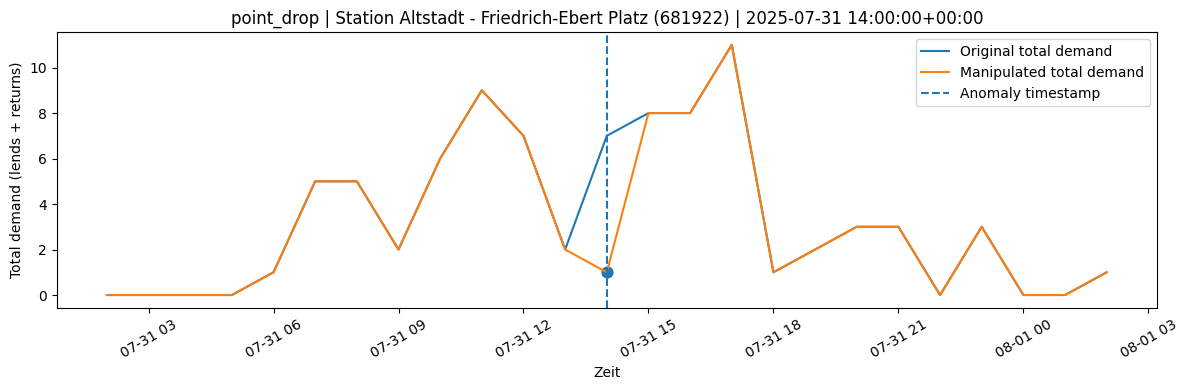

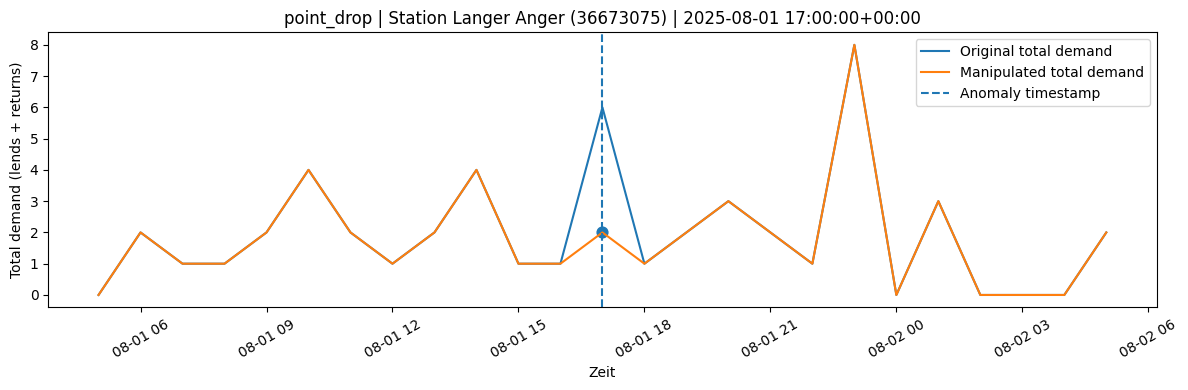

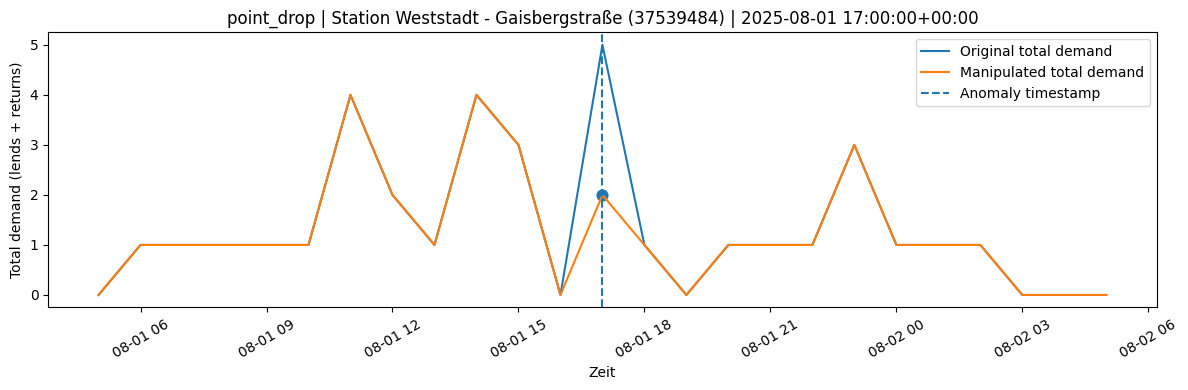

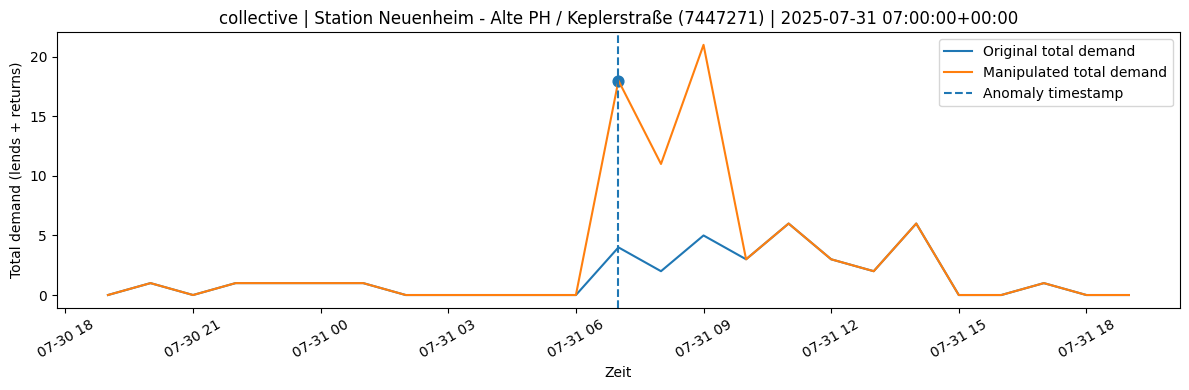

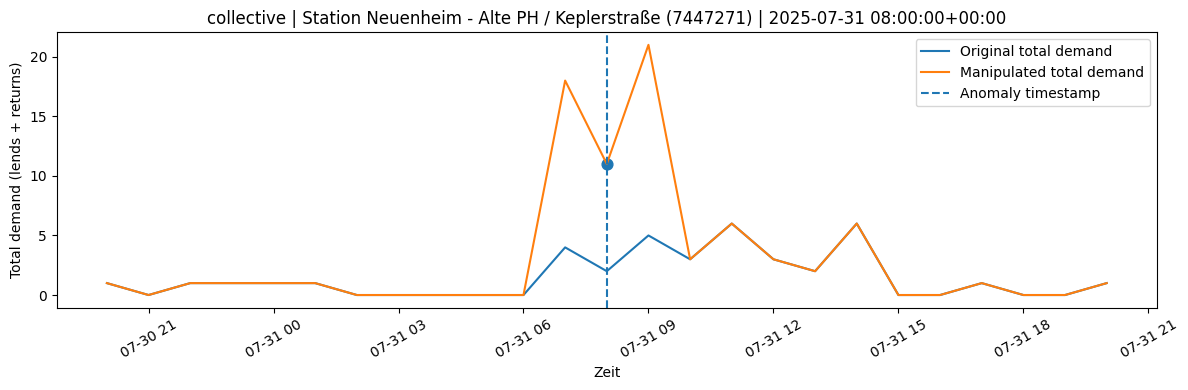

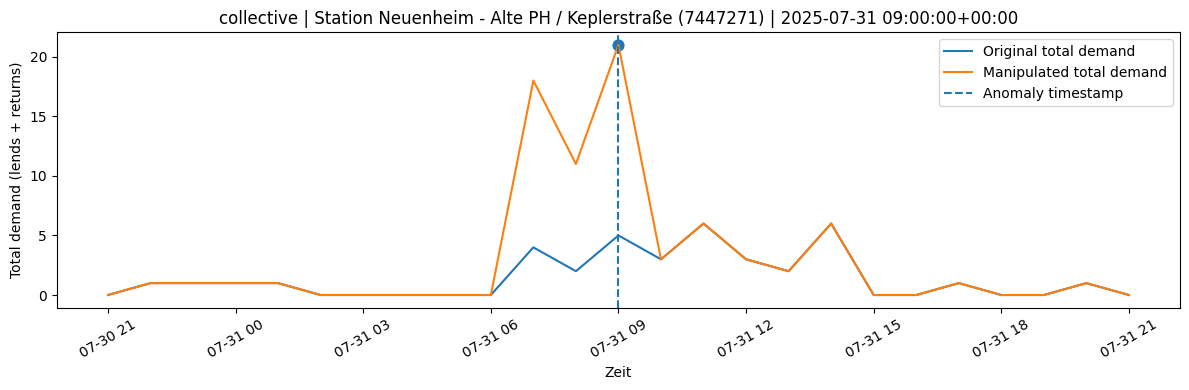

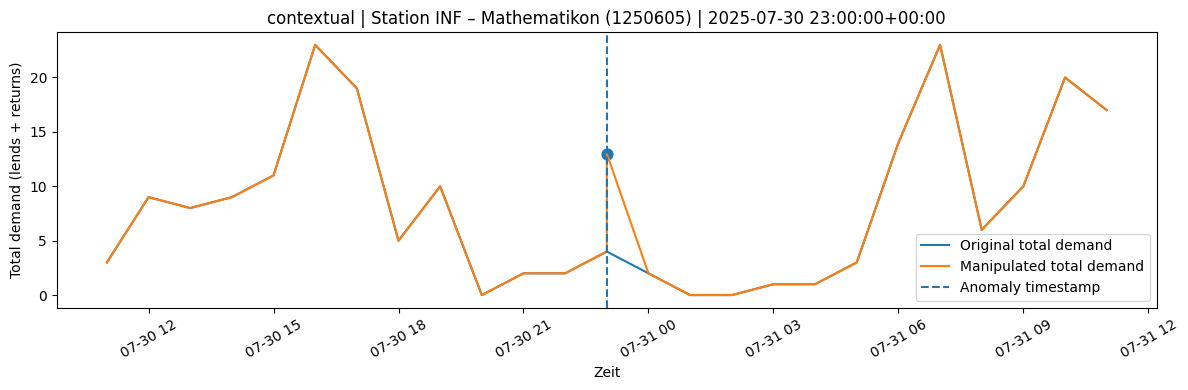

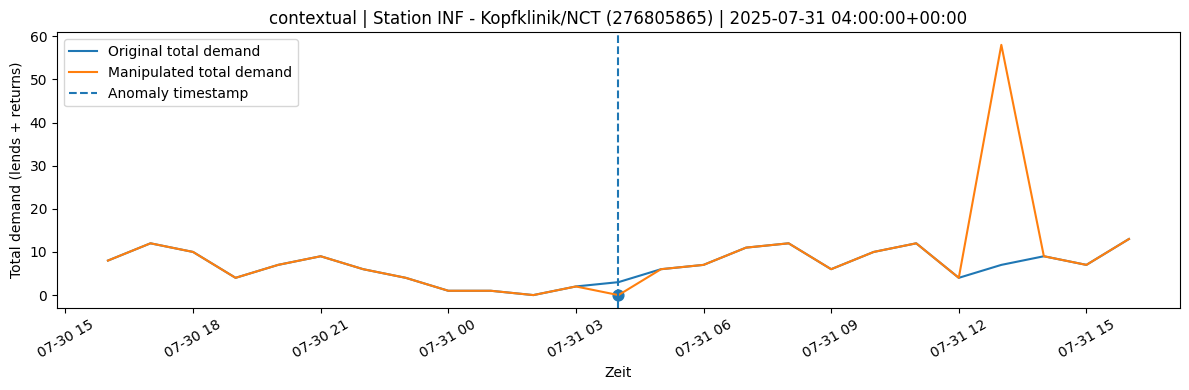

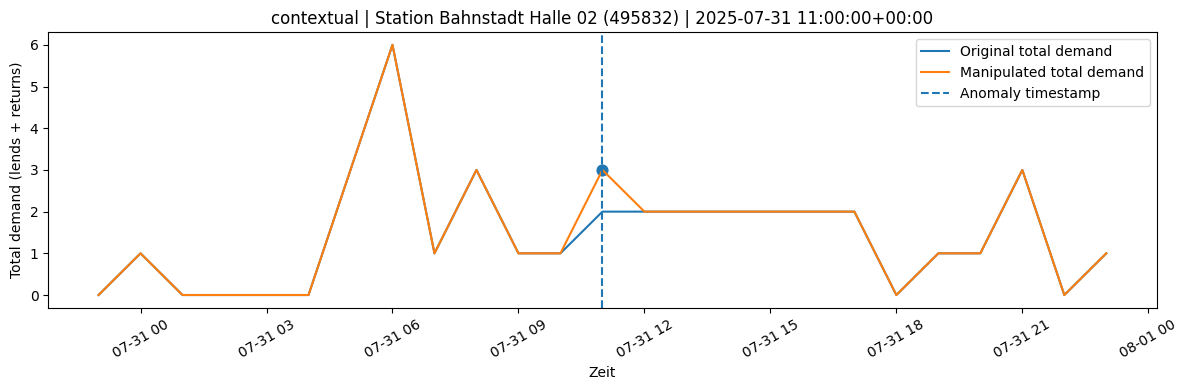

Gezeigte Fenster: 9


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# VIS 1 — Beispiel-Fenster: Original vs manipuliert je Anomalie
# ============================================================

plot_df = df_hd_inj_balanced.copy()

if "station_name" not in plot_df.columns:
    plot_df["station_name"] = plot_df["station_id"].astype(str)

plot_df["hour_ts"] = pd.to_datetime(plot_df["hour_ts"], utc=True)
plot_df["orig_total"] = plot_df["original_n_lends"] + plot_df["original_n_returns"]
plot_df["new_total"]  = plot_df["n_lends"] + plot_df["n_returns"]

TARGET_TYPES = ["point_drop", "collective", "contextual"]
N_PER_TYPE = 3
WINDOW = 12   # Stunden links/rechts

fig_count = 0

for atype in TARGET_TYPES:
    sub = plot_df[
        (plot_df["synth_label"] == 1) &
        (plot_df["synth_type"] == atype)
    ].sort_values("hour_ts").copy()

    if sub.empty:
        print(f"Keine Beispiele für {atype}")
        continue

    # bei collective nicht alle Zeilen eines Blocks, sondern etwas ausgedünnt
    sub = sub.drop_duplicates(subset=["station_id", "hour_ts"]).head(N_PER_TYPE)

    for _, row in sub.iterrows():
        station = row["station_id"]
        ts = row["hour_ts"]

        station_df = plot_df[plot_df["station_id"] == station].sort_values("hour_ts").copy()
        mask = (station_df["hour_ts"] >= ts - pd.Timedelta(hours=WINDOW)) & \
               (station_df["hour_ts"] <= ts + pd.Timedelta(hours=WINDOW))
        win = station_df.loc[mask].copy()

        if len(win) < 2:
            continue

        fig_count += 1
        plt.figure(figsize=(12, 4))
        plt.plot(win["hour_ts"], win["orig_total"], label="Original total demand")
        plt.plot(win["hour_ts"], win["new_total"], label="Manipulated total demand")
        plt.axvline(ts, linestyle="--", label="Anomaly timestamp")
        plt.scatter([ts], [row["new_total"]], s=60)

        plt.title(f"{atype} | Station {row['station_name']} ({station}) | {ts}")
        plt.xlabel("Zeit")
        plt.ylabel("Total demand (lends + returns)")
        plt.legend()
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

print(f"Gezeigte Fenster: {fig_count}")

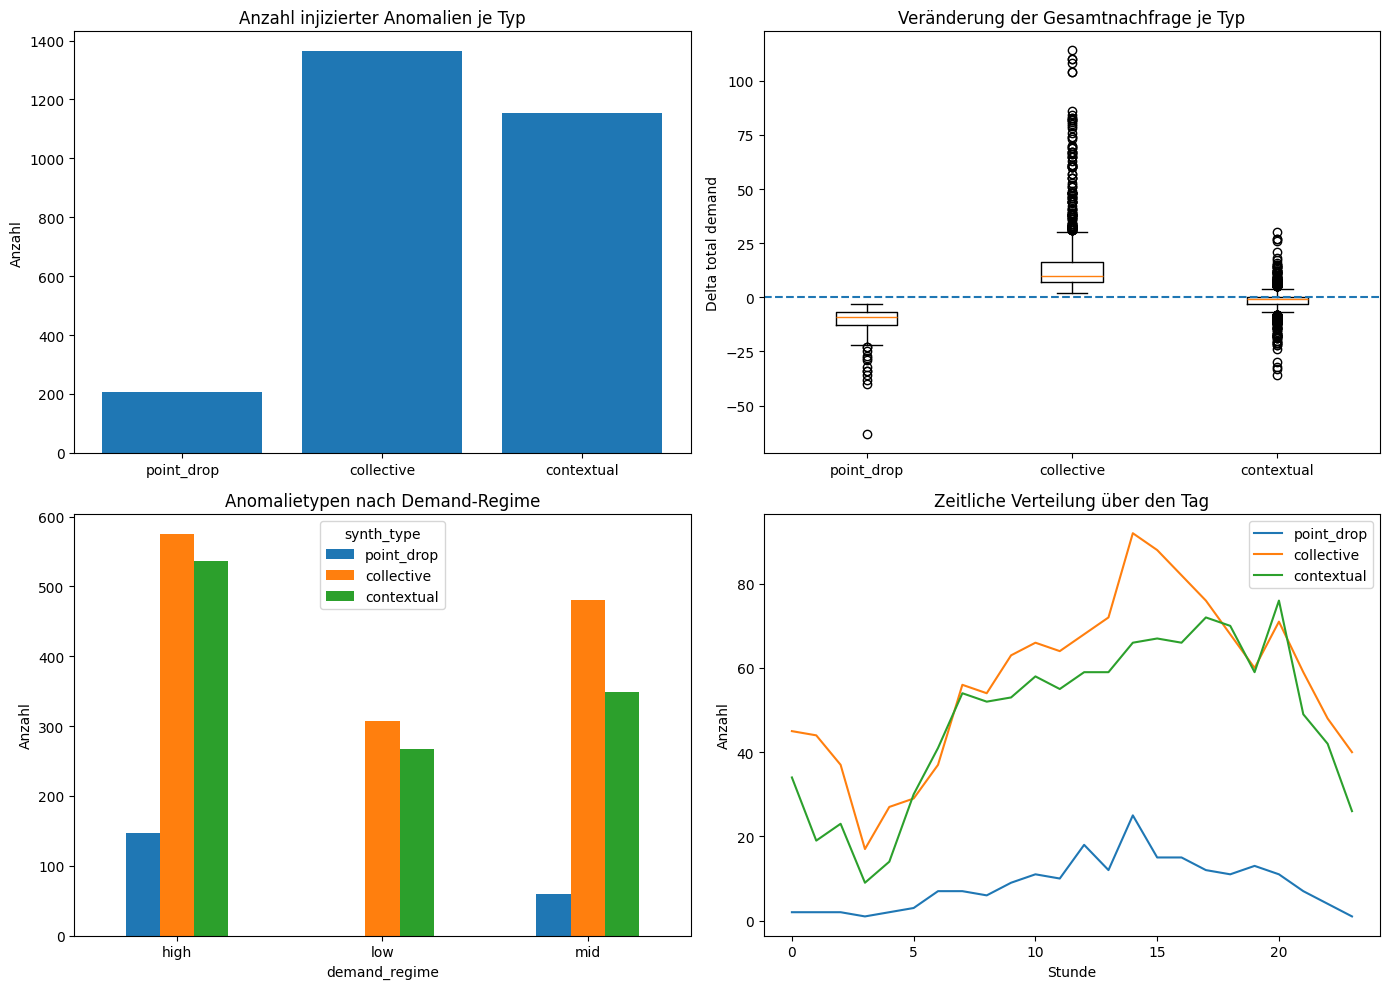

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dfv = df_hd_inj_balanced.copy()
dfv["hour_ts"] = pd.to_datetime(dfv["hour_ts"], utc=True)

# station_name fallback
if "station_name" not in dfv.columns:
    dfv["station_name"] = dfv["station_id"].astype(str)

dfv["orig_total"] = dfv["original_n_lends"] + dfv["original_n_returns"]
dfv["new_total"]  = dfv["n_lends"] + dfv["n_returns"]
dfv["delta_total"] = dfv["new_total"] - dfv["orig_total"]
dfv["hour_of_day"] = dfv["hour_ts"].dt.hour

anom = dfv[
    (dfv["synth_label"] == 1) &
    (dfv["synth_type"].isin(["point_drop", "collective", "contextual"]))
].copy()

types = ["point_drop", "collective", "contextual"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Anzahl je Typ
counts = anom["synth_type"].value_counts().reindex(types).fillna(0)
axes[0, 0].bar(counts.index, counts.values)
axes[0, 0].set_title("Anzahl injizierter Anomalien je Typ")
axes[0, 0].set_ylabel("Anzahl")

# 2) Delta-Verteilung je Typ
data = [anom.loc[anom["synth_type"] == t, "delta_total"].dropna().values for t in types]
axes[0, 1].boxplot(data, tick_labels=types)
axes[0, 1].axhline(0, linestyle="--")
axes[0, 1].set_title("Veränderung der Gesamtnachfrage je Typ")
axes[0, 1].set_ylabel("Delta total demand")

# 3) Demand-Regime x Typ
reg_ct = pd.crosstab(anom["demand_regime"], anom["synth_type"]).reindex(columns=types).fillna(0)
reg_ct.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Anomalietypen nach Demand-Regime")
axes[1, 0].set_ylabel("Anzahl")
axes[1, 0].tick_params(axis="x", rotation=0)

# 4) Stunde des Tages x Typ
hour_ct = pd.crosstab(anom["hour_of_day"], anom["synth_type"]).reindex(columns=types).fillna(0)
for t in types:
    axes[1, 1].plot(hour_ct.index, hour_ct[t], label=t)
axes[1, 1].set_title("Zeitliche Verteilung über den Tag")
axes[1, 1].set_xlabel("Stunde")
axes[1, 1].set_ylabel("Anzahl")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

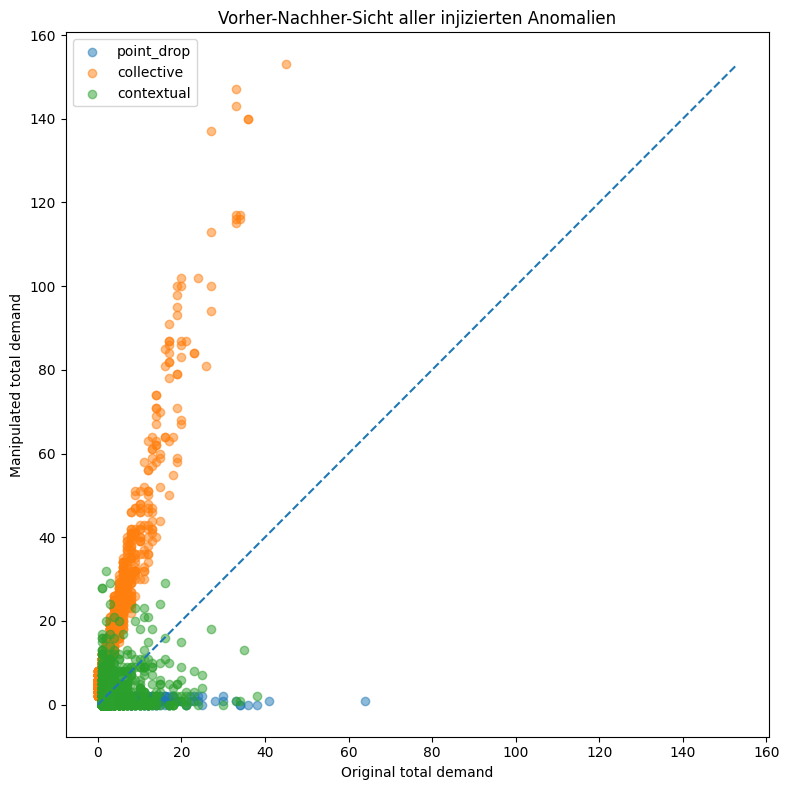

In [26]:
plt.figure(figsize=(8, 8))

for t in ["point_drop", "collective", "contextual"]:
    sub = anom[anom["synth_type"] == t]
    plt.scatter(
        sub["orig_total"],
        sub["new_total"],
        alpha=0.5,
        label=t
    )

mx = max(anom["orig_total"].max(), anom["new_total"].max())
plt.plot([0, mx], [0, mx], linestyle="--")
plt.xlabel("Original total demand")
plt.ylabel("Manipulated total demand")
plt.title("Vorher-Nachher-Sicht aller injizierten Anomalien")
plt.legend()
plt.tight_layout()
plt.show()

,station_id,start,end,length,mean_delta,sum_delta
238,276805865,2026-01-07 07:00:00+00:00,2026-01-07 12:00:00+00:00,6,16.00,96
12,121354,2025-11-23 15:00:00+00:00,2025-11-23 18:00:00+00:00,4,22.25,89
576,78599753,2026-01-11 10:00:00+00:00,2026-01-11 13:00:00+00:00,4,8.00,32
436,59655887,2025-09-15 05:00:00+00:00,2025-09-15 08:00:00+00:00,4,5.25,21
56,121361,2025-10-30 15:00:00+00:00,2025-10-30 18:00:00+00:00,4,37.00,148
441,59655887,2025-11-30 01:00:00+00:00,2025-11-30 04:00:00+00:00,4,5.75,23
440,59655887,2025-11-10 12:00:00+00:00,2025-11-10 15:00:00+00:00,4,8.50,34
442,59655887,2025-12-06 11:00:00+00:00,2025-12-06 14:00:00+00:00,4,7.00,28
443,59656724,2025-08-01 14:00:00+00:00,2025-08-01 17:00:00+00:00,4,23.00,92
447,59656724,2025-08-25 14:00:00+00:00,2025-08-25 17:00:00+00:00,4,16.50,66


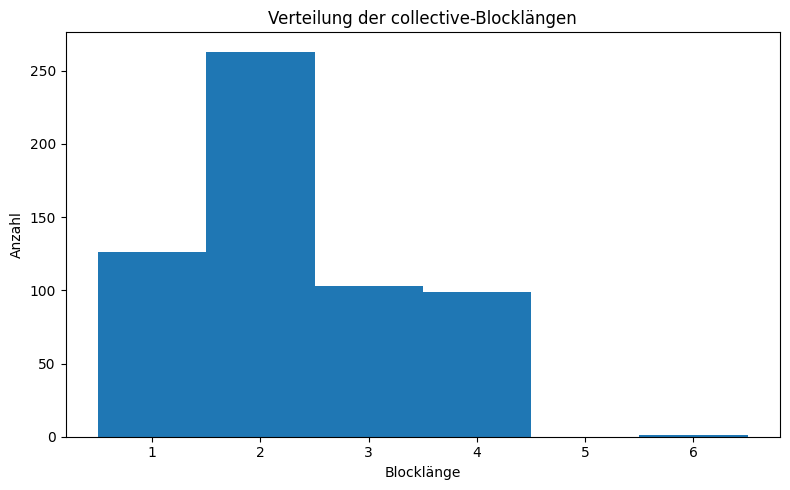

In [27]:
cdf = anom[anom["synth_type"] == "collective"].copy().sort_values(["station_id", "hour_ts"])

blocks = []
for station_id, g in cdf.groupby("station_id"):
    g = g.sort_values("hour_ts").copy()
    step = g["hour_ts"].diff().dt.total_seconds().div(3600)
    g["new_block"] = step.ne(1) | step.isna()
    g["block_id"] = g["new_block"].cumsum()

    for bid, b in g.groupby("block_id"):
        blocks.append({
            "station_id": station_id,
            "start": b["hour_ts"].min(),
            "end": b["hour_ts"].max(),
            "length": len(b),
            "mean_delta": b["delta_total"].mean(),
            "sum_delta": b["delta_total"].sum()
        })

blocks_df = pd.DataFrame(blocks)
display(blocks_df.sort_values("length", ascending=False).head(20))

plt.figure(figsize=(8, 5))
plt.hist(blocks_df["length"], bins=np.arange(1, blocks_df["length"].max() + 2) - 0.5)
plt.xlabel("Blocklänge")
plt.ylabel("Anzahl")
plt.title("Verteilung der collective-Blocklängen")
plt.tight_layout()
plt.show()

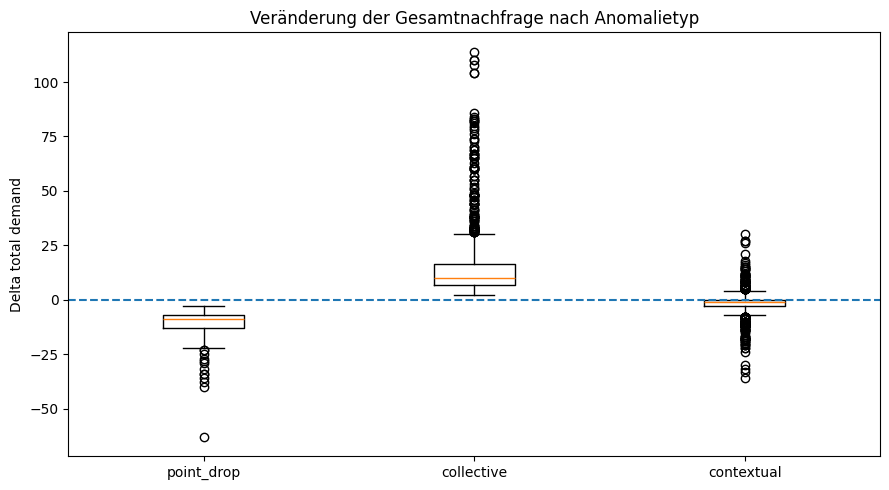

In [22]:
import matplotlib.pyplot as plt

# ============================================================
# VIS 2 — Delta-Verteilung pro Typ
# ============================================================

delta_df = df_hd_inj_balanced.copy()
delta_df["orig_total"] = delta_df["original_n_lends"] + delta_df["original_n_returns"]
delta_df["new_total"]  = delta_df["n_lends"] + delta_df["n_returns"]
delta_df["delta_total"] = delta_df["new_total"] - delta_df["orig_total"]

delta_df = delta_df[
    (delta_df["synth_label"] == 1) &
    (delta_df["synth_type"].isin(["point_drop", "collective", "contextual"]))
].copy()

types = ["point_drop", "collective", "contextual"]
data = [delta_df.loc[delta_df["synth_type"] == t, "delta_total"].dropna().values for t in types]

plt.figure(figsize=(9, 5))
plt.boxplot(data, tick_labels=types)
plt.axhline(0, linestyle="--")
plt.ylabel("Delta total demand")
plt.title("Veränderung der Gesamtnachfrage nach Anomalietyp")
plt.tight_layout()
plt.show()

,station_id,start,end,length
238,276805865,2026-01-07 07:00:00+00:00,2026-01-07 12:00:00+00:00,6
253,339517,2025-07-31 20:00:00+00:00,2025-07-31 23:00:00+00:00,4
443,59656724,2025-08-01 14:00:00+00:00,2025-08-01 17:00:00+00:00,4
579,79153997,2025-08-04 15:00:00+00:00,2025-08-04 18:00:00+00:00,4
228,27195756,2025-08-06 06:00:00+00:00,2025-08-06 09:00:00+00:00,4
71,121368,2025-08-13 22:00:00+00:00,2025-08-14 01:00:00+00:00,4
278,344831,2025-08-16 00:00:00+00:00,2025-08-16 03:00:00+00:00,4
254,339517,2025-08-19 11:00:00+00:00,2025-08-19 14:00:00+00:00,4
255,339517,2025-08-24 07:00:00+00:00,2025-08-24 10:00:00+00:00,4
233,276805865,2025-08-24 14:00:00+00:00,2025-08-24 17:00:00+00:00,4


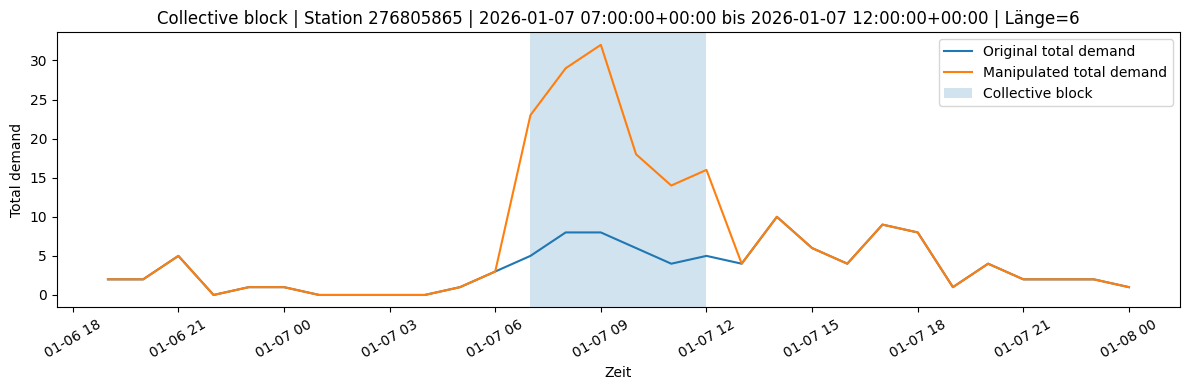

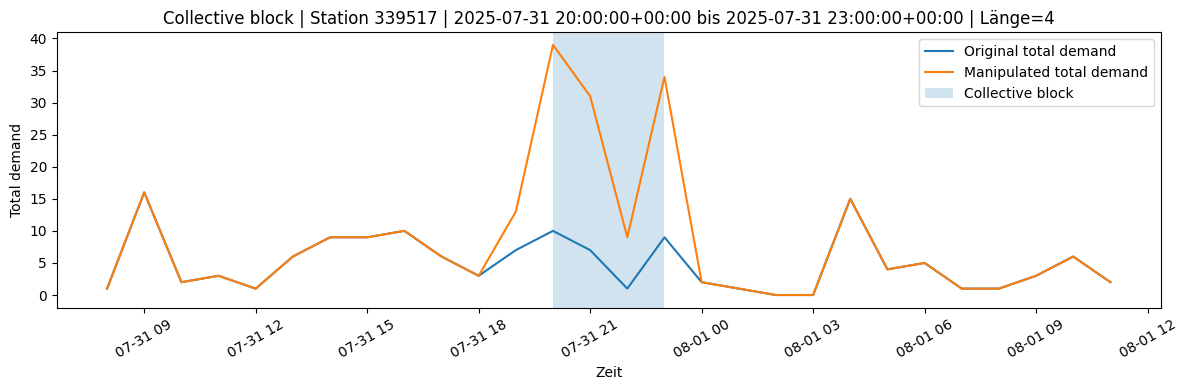

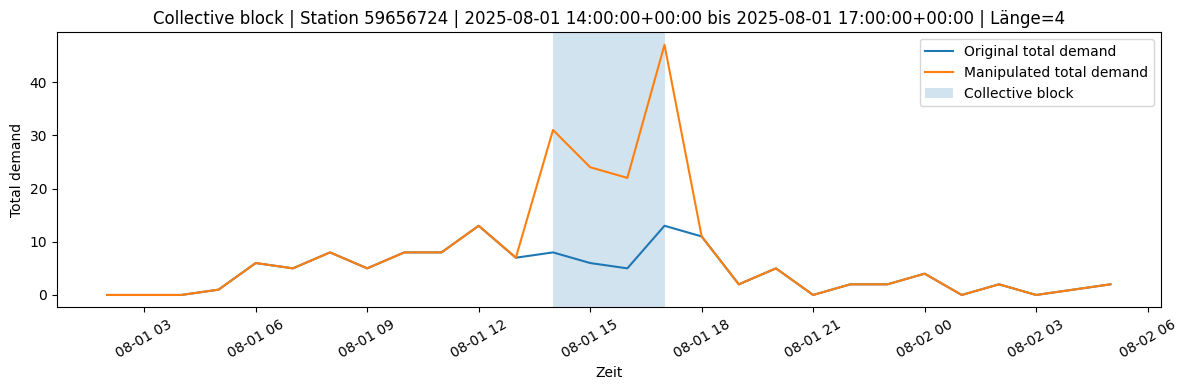

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# VIS 3 — Collective-Blöcke erkennen und visualisieren
# ============================================================

cdf = df_hd_inj_balanced.copy()
cdf["hour_ts"] = pd.to_datetime(cdf["hour_ts"], utc=True)
cdf["orig_total"] = cdf["original_n_lends"] + cdf["original_n_returns"]
cdf["new_total"]  = cdf["n_lends"] + cdf["n_returns"]

collective = cdf[
    (cdf["synth_label"] == 1) &
    (cdf["synth_type"] == "collective")
].sort_values(["station_id", "hour_ts"]).copy()

blocks = []

for station_id, g in collective.groupby("station_id"):
    g = g.sort_values("hour_ts").copy()
    step = g["hour_ts"].diff().dt.total_seconds().div(3600)
    g["new_block"] = (step != 1) | (step.isna())
    g["block_id"] = g["new_block"].cumsum()

    for bid, b in g.groupby("block_id"):
        blocks.append({
            "station_id": station_id,
            "start": b["hour_ts"].min(),
            "end": b["hour_ts"].max(),
            "length": len(b)
        })

blocks_df = pd.DataFrame(blocks).sort_values(["length", "start"], ascending=[False, True])
display(blocks_df.head(10))

# die 3 längsten / interessantesten Blöcke plotten
for _, blk in blocks_df.head(3).iterrows():
    station = blk["station_id"]
    start = blk["start"]
    end = blk["end"]

    station_df = cdf[cdf["station_id"] == station].sort_values("hour_ts").copy()
    mask = (station_df["hour_ts"] >= start - pd.Timedelta(hours=12)) & \
           (station_df["hour_ts"] <= end + pd.Timedelta(hours=12))
    win = station_df.loc[mask].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(win["hour_ts"], win["orig_total"], label="Original total demand")
    plt.plot(win["hour_ts"], win["new_total"], label="Manipulated total demand")
    plt.axvspan(start, end, alpha=0.2, label="Collective block")

    plt.title(f"Collective block | Station {station} | {start} bis {end} | Länge={blk['length']}")
    plt.xlabel("Zeit")
    plt.ylabel("Total demand")
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [ ]:
# ==============================================================
# Mannheim laden + Anomalien injizieren + Details anzeigen
# ==============================================================

CITY = "Mannheim"
SCENARIO = "balanced"   # alternativ: "point_heavy"
SEED = 42

print(f"[1/3] {CITY} laden + vorbereiten...")
df_ma, sp_ma, train_end_ma, val_end_ma = prepare_city_data(
    target_demand_path, geo_path, station_names_path, cfg, CITY
)

print(f"[2/3] Anomalien für {CITY} injizieren...")
df_ma_inj = inject_synthetic_anomalies_v13(
    df_ma,
    test_start=val_end_ma,
    scenario=SCENARIO,
    injection_rate=0.015,
    seed=SEED,
    verbose=True
)

print(f"[3/3] Detailtabelle für {CITY} bauen...")

out = df_ma_inj.copy()

# Falls station_name nicht existiert, sauber fallbacken
if "station_name" not in out.columns:
    out["station_name"] = out["station_id"].astype(str)

out["original_total_demand"] = out["original_n_lends"] + out["original_n_returns"]
out["new_total_demand"] = out["n_lends"] + out["n_returns"]
out["delta_lends"] = out["n_lends"] - out["original_n_lends"]
out["delta_returns"] = out["n_returns"] - out["original_n_returns"]
out["delta_total_demand"] = out["new_total_demand"] - out["original_total_demand"]

inspect_cols = [
    "station_id", "station_name", "hour_ts", "demand_regime",
    "original_n_lends", "n_lends",
    "original_n_returns", "n_returns",
    "original_total_demand", "new_total_demand",
    "delta_lends", "delta_returns", "delta_total_demand",
    "synth_type", "synth_label"
]

anomaly_details_ma = out[
    (out["synth_label"] == 1) &
    (out["synth_type"].isin(["point_drop", "collective", "contextual"]))
][inspect_cols].sort_values(["synth_type", "hour_ts"]).reset_index(drop=True)

print(f"\nGefundene injizierte Anomalien in {CITY}: {len(anomaly_details_ma)}")
display(anomaly_details_ma.head(100))

In [ ]:
for city, df_details in [("Heidelberg", anomaly_details), ("Mannheim", anomaly_details_ma)]:
    print(f"\n===== {city} =====")
    print(df_details["synth_type"].value_counts(dropna=False))

In [18]:
# ══════════════════════════════════════════════════════════════
# 14b -- Injektionsstatistik pro Szenario
# ══════════════════════════════════════════════════════════════
def summarize_injection_scenario_v13(
    df_injected: pd.DataFrame,
    cfg,
    val_start: pd.Timestamp,
    test_start: pd.Timestamp,
    scenario_name: str,
    verbose: bool = True
) -> pd.DataFrame:
    x = df_injected.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

    row_mask_val  = (x["hour_ts"] >= val_start) & (x["hour_ts"] < test_start)
    row_mask_test = x["hour_ts"] >= test_start

    seq_base = x.dropna(subset=cfg.ae_features).copy()
    _, meta_seq = make_sequences_with_window_labels(
        seq_base,
        feature_cols=cfg.ae_features,
        window_size=cfg.ae_window_size,
        synth_label_col="synth_label",
        synth_type_col="synth_type",
        require_contiguous=cfg.require_contiguous,
        agg_minutes=cfg.aggregation_minutes
    )

    seq_mask_val  = (meta_seq["hour_ts"] >= val_start) & (meta_seq["hour_ts"] < test_start)
    seq_mask_test = meta_seq["hour_ts"] >= test_start

    type_order = ["point_spike", "point_drop", "contextual", "collective"]

    stats = {
        "Scenario": scenario_name,

        "Rows_Val_Total": int(row_mask_val.sum()),
        "Rows_Val_Anom": int(x.loc[row_mask_val, "synth_label"].sum()),
        "Rows_Val_AnomRatePct": float(x.loc[row_mask_val, "synth_label"].mean() * 100) if row_mask_val.sum() else np.nan,

        "Rows_Test_Total": int(row_mask_test.sum()),
        "Rows_Test_Anom": int(x.loc[row_mask_test, "synth_label"].sum()),
        "Rows_Test_AnomRatePct": float(x.loc[row_mask_test, "synth_label"].mean() * 100) if row_mask_test.sum() else np.nan,

        "Seq_Val_Total": int(seq_mask_val.sum()),
        "Seq_Val_LastStepAnom": int(meta_seq.loc[seq_mask_val, "synth_label"].sum()),
        "Seq_Val_LastStepRatePct": float(meta_seq.loc[seq_mask_val, "synth_label"].mean() * 100) if seq_mask_val.sum() else np.nan,
        "Seq_Val_WindowAnom": int(meta_seq.loc[seq_mask_val, "window_synth_label"].sum()),
        "Seq_Val_WindowRatePct": float(meta_seq.loc[seq_mask_val, "window_synth_label"].mean() * 100) if seq_mask_val.sum() else np.nan,

        "Seq_Test_Total": int(seq_mask_test.sum()),
        "Seq_Test_LastStepAnom": int(meta_seq.loc[seq_mask_test, "synth_label"].sum()),
        "Seq_Test_LastStepRatePct": float(meta_seq.loc[seq_mask_test, "synth_label"].mean() * 100) if seq_mask_test.sum() else np.nan,
        "Seq_Test_WindowAnom": int(meta_seq.loc[seq_mask_test, "window_synth_label"].sum()),
        "Seq_Test_WindowRatePct": float(meta_seq.loc[seq_mask_test, "window_synth_label"].mean() * 100) if seq_mask_test.sum() else np.nan,
    }

    for atype in type_order:
        stats[f"Val_{atype}"] = int(((x["synth_type"] == atype) & row_mask_val).sum())
        stats[f"Test_{atype}"] = int(((x["synth_type"] == atype) & row_mask_test).sum())

    stats_df = pd.DataFrame([stats])

    if verbose:
        print(f"\n{'='*110}")
        print(f"  INJEKTIONSSTATISTIK -- {scenario_name}")
        print(f"{'='*110}")
        show_cols = [
            "Scenario",
            "Rows_Val_Total", "Rows_Val_Anom", "Rows_Val_AnomRatePct",
            "Rows_Test_Total", "Rows_Test_Anom", "Rows_Test_AnomRatePct",
            "Seq_Val_Total", "Seq_Val_LastStepAnom", "Seq_Val_LastStepRatePct", "Seq_Val_WindowAnom", "Seq_Val_WindowRatePct",
            "Seq_Test_Total", "Seq_Test_LastStepAnom", "Seq_Test_LastStepRatePct", "Seq_Test_WindowAnom", "Seq_Test_WindowRatePct",
            "Val_point_spike", "Val_point_drop", "Val_contextual", "Val_collective",
            "Test_point_spike", "Test_point_drop", "Test_contextual", "Test_collective",
        ]
        print(stats_df[show_cols].to_string(index=False, float_format="{:.2f}".format))

    return stats_df

In [19]:
# ══════════════════════════════════════════════════════════════
# 15 -- V13 Evaluation: Per-Type PR-AUC + Threshold aus VAL
# ══════════════════════════════════════════════════════════════
def evaluate_against_synthetic_v13(
    model,
    df_injected: pd.DataFrame,
    scaler: StandardScaler,
    cfg,
    val_start: pd.Timestamp,
    test_start: pd.Timestamp,
    experiment_name: str,
    verbose: bool = True
) -> Dict:
    """
    V13-Evaluation mit:
    - Last-Step PR-AUC als Primärmetrik auf TEST
    - Threshold-Selektion ausschließlich auf VAL
    - Per-Type PR-AUC auf TEST
    - Window-Level als Sekundärmetrik auf TEST
    """
    ae_features        = cfg.ae_features
    ae_target_features = cfg.ae_target_features if cfg.ae_target_features is not None else cfg.ae_features

    df_ae = df_injected.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    df_ae = df_ae.dropna(subset=ae_features).copy()

    df_ae_scaled = df_ae.copy()
    df_ae_scaled[ae_features] = scaler.transform(df_ae[ae_features])

    for col in ["synth_label", "synth_type", "original_n_lends", "original_n_returns"]:
        if col in df_ae.columns:
            df_ae_scaled[col] = df_ae[col].values

    X_all, meta_all = make_sequences_with_window_labels(
        df_ae_scaled,
        feature_cols=ae_features,
        window_size=cfg.ae_window_size,
        synth_label_col="synth_label",
        synth_type_col="synth_type",
        require_contiguous=cfg.require_contiguous,
        agg_minutes=cfg.aggregation_minutes
    )

    meta_all["split_eval"] = np.where(
        meta_all["hour_ts"] < val_start, "train",
        np.where(meta_all["hour_ts"] < test_start, "val", "test")
    )

    X_hat_all = predict_in_batches(model, X_all, batch_size=cfg.eval_batch_size)
    all_scores = compute_ae_scores_from_predictions(
        X_all,
        X_hat_all,
        input_features=ae_features,
        target_features=ae_target_features,
        score_features=cfg.ae_score_features,
        score_mode=cfg.score_mode,
        weighted_alpha_last=cfg.weighted_alpha_last,
    )
    meta_all["ae_score_raw"] = all_scores

    val_meta  = meta_all[meta_all["split_eval"] == "val"].copy()
    test_meta = meta_all[meta_all["split_eval"] == "test"].copy()

    if len(val_meta) == 0 or len(test_meta) == 0:
        print("  WARNUNG: Keine VAL- oder TEST-Sequenzen vorhanden!")
        return {}

    results = {
        "experiment": experiment_name,
        "n_val": len(val_meta),
        "n_test": len(test_meta),
        "score_mode": cfg.score_mode,
        "threshold_source": "validation_best_f1_last_step",
    }

    # ── Threshold auf VAL bestimmen ──
    y_val = val_meta["synth_label"].astype(int).values
    s_val = val_meta["ae_score_raw"].values

    if len(np.unique(y_val)) > 1:
        prec_val, rec_val, thr_val = precision_recall_curve(y_val, s_val)

        if len(thr_val) > 0:
            f1_val = 2 * prec_val[:-1] * rec_val[:-1] / (prec_val[:-1] + rec_val[:-1] + 1e-10)
            best_val = np.argmax(f1_val)

            results["val_pr_auc"]         = average_precision_score(y_val, s_val)
            results["val_roc_auc"]        = roc_auc_score(y_val, s_val)
            results["val_best_f1"]        = f1_val[best_val]
            results["val_best_precision"] = prec_val[best_val]
            results["val_best_recall"]    = rec_val[best_val]
            results["val_best_threshold"] = float(thr_val[best_val])
        else:
            results["val_pr_auc"] = average_precision_score(y_val, s_val)
            results["val_roc_auc"] = roc_auc_score(y_val, s_val)
            results["val_best_f1"] = None
            results["val_best_threshold"] = None
    else:
        results["val_pr_auc"] = results["val_roc_auc"] = results["val_best_f1"] = None
        results["val_best_threshold"] = None

    # ── TEST Last-Step (Primärmetrik) ──
    y_true_ls = test_meta["synth_label"].astype(int).values
    y_score   = test_meta["ae_score_raw"].values

    if len(np.unique(y_true_ls)) > 1:
        results["ls_pr_auc"]  = average_precision_score(y_true_ls, y_score)
        results["ls_roc_auc"] = roc_auc_score(y_true_ls, y_score)
    else:
        results["ls_pr_auc"] = results["ls_roc_auc"] = None

    if results.get("val_best_threshold") is not None:
        thr = results["val_best_threshold"]
        y_pred_ls = (y_score >= thr).astype(int)

        results["ls_precision_at_val_threshold"] = precision_score(y_true_ls, y_pred_ls, zero_division=0)
        results["ls_recall_at_val_threshold"]    = recall_score(y_true_ls, y_pred_ls, zero_division=0)
        results["ls_f1_at_val_threshold"]        = f1_score(y_true_ls, y_pred_ls, zero_division=0)

        # optional fuer bestehende Downstream-Zellen
        results["ls_best_threshold"] = thr
        results["ls_best_f1"]        = results["ls_f1_at_val_threshold"]
        results["ls_best_precision"] = results["ls_precision_at_val_threshold"]
        results["ls_best_recall"]    = results["ls_recall_at_val_threshold"]
    else:
        results["ls_precision_at_val_threshold"] = None
        results["ls_recall_at_val_threshold"]    = None
        results["ls_f1_at_val_threshold"]        = None
        results["ls_best_threshold"]             = None
        results["ls_best_f1"]                    = None
        results["ls_best_precision"]             = None
        results["ls_best_recall"]                = None

    # ── TEST Window-Level (Sekundärmetrik) ──
    y_true_win = test_meta["window_synth_label"].astype(int).values
    if len(np.unique(y_true_win)) > 1:
        results["win_pr_auc"]  = average_precision_score(y_true_win, y_score)
        results["win_roc_auc"] = roc_auc_score(y_true_win, y_score)

        if results.get("val_best_threshold") is not None:
            y_pred_win = (y_score >= results["val_best_threshold"]).astype(int)
            results["win_f1_at_val_threshold"] = f1_score(y_true_win, y_pred_win, zero_division=0)
            results["win_best_f1"] = results["win_f1_at_val_threshold"]  # fuer bestehende Downstream-Zellen
        else:
            results["win_f1_at_val_threshold"] = None
            results["win_best_f1"] = None
    else:
        results["win_pr_auc"] = results["win_roc_auc"] = None
        results["win_f1_at_val_threshold"] = None
        results["win_best_f1"] = None

    # ── Per-Type PR-AUC auf TEST ──
    results["per_type"] = {}
    for atype in ["point_spike", "point_drop", "contextual", "collective"]:
        type_mask   = test_meta["synth_type"] == atype
        normal_mask = test_meta["synth_label"] == 0

        sub = test_meta[type_mask | normal_mask].copy()
        if len(sub) == 0 or type_mask.sum() == 0:
            results["per_type"][atype] = {
                "n": int(type_mask.sum()),
                "pr_auc": None,
                "roc_auc": None,
                "best_f1": None,
                "detection_rate": None
            }
            continue

        y_t = (sub["synth_type"] == atype).astype(int).values
        y_s = sub["ae_score_raw"].values
        info = {"n": int(type_mask.sum())}

        if len(np.unique(y_t)) > 1:
            info["pr_auc"]  = average_precision_score(y_t, y_s)
            info["roc_auc"] = roc_auc_score(y_t, y_s)
        else:
            info["pr_auc"] = info["roc_auc"] = None

        if results.get("val_best_threshold") is not None:
            thr = results["val_best_threshold"]
            type_seqs = test_meta[type_mask]
            detected = (type_seqs["ae_score_raw"] >= thr).sum()
            info["detection_rate"] = detected / len(type_seqs) if len(type_seqs) > 0 else 0.0
        else:
            info["detection_rate"] = None

        results["per_type"][atype] = info

    if verbose:
        n_val_ls   = int(val_meta["synth_label"].sum())
        n_test_ls  = int(test_meta["synth_label"].sum())
        n_test_win = int(test_meta["window_synth_label"].sum())

        print(f"  [{experiment_name}]")
        print(f"    VAL-Sequenzen:  {len(val_meta):,}")
        print(f"    TEST-Sequenzen: {len(test_meta):,}")
        print(f"    VAL Last-Step Anomalien:  {n_val_ls:,} ({n_val_ls/len(val_meta)*100:.2f}%)")
        print(f"    TEST Last-Step Anomalien: {n_test_ls:,} ({n_test_ls/len(test_meta)*100:.2f}%)")
        print(f"    TEST Window-Anomalien:    {n_test_win:,} ({n_test_win/len(test_meta)*100:.2f}%)")
        print(f"    --- VAL Threshold-Selektion ---")
        print(f"    VAL PR-AUC: {results.get('val_pr_auc', 'N/A')}")
        if results.get("val_best_f1") is not None:
            print(
                f"    VAL Best F1: {results['val_best_f1']:.4f} "
                f"(P={results['val_best_precision']:.4f}, R={results['val_best_recall']:.4f}, "
                f"Thr={results['val_best_threshold']:.6f})"
            )
        print(f"    --- TEST Last-Step (Primaer) ---")
        print(f"    PR-AUC:  {results.get('ls_pr_auc', 'N/A')}")
        print(f"    ROC-AUC: {results.get('ls_roc_auc', 'N/A')}")
        if results.get("ls_f1_at_val_threshold") is not None:
            print(
                f"    F1@VAL-Threshold: {results['ls_f1_at_val_threshold']:.4f} "
                f"(P={results['ls_precision_at_val_threshold']:.4f}, "
                f"R={results['ls_recall_at_val_threshold']:.4f})"
            )
        print(f"    --- TEST Window (Sekundaer) ---")
        print(f"    PR-AUC: {results.get('win_pr_auc', 'N/A')}")
        if results.get("win_f1_at_val_threshold") is not None:
            print(f"    F1@VAL-Threshold: {results['win_f1_at_val_threshold']:.4f}")
        print(f"    --- TEST Per-Type PR-AUC ---")
        for atype, info in results["per_type"].items():
            pr = info.get("pr_auc")
            dr = info.get("detection_rate")
            n  = info.get("n", 0)
            pr_str = f"{pr:.4f}" if pr is not None else "N/A"
            dr_str = f"{dr:.2%}" if dr is not None else "N/A"
            print(f"    {atype:15s}: n={n:5d}, PR-AUC={pr_str}, DR={dr_str}")

    results["meta"] = test_meta
    results["meta_val"] = val_meta
    return results

In [ ]:
# ══════════════════════════════════════════════════════════════
# 16 -- V13 Isolation Forest Baseline
# ══════════════════════════════════════════════════════════════
def run_isolation_forest_baseline(
    df_injected: pd.DataFrame,
    df_clean: pd.DataFrame,
    train_end: pd.Timestamp,
    test_start: pd.Timestamp,
    cfg,
    experiment_name: str = "IsolationForest",
    n_estimators: int = 200,
    contamination: float = 0.01,
    verbose: bool = True
) -> Dict:
    '''
    Isolation Forest auf denselben Features wie der LSTM-AE.
    Trainiert auf normalen Daten aus dem Trainingsset der SAUBEREN Daten,
    evaluiert auf dem injizierten Testset.

    Zwei Modi:
    - flat: Features des aktuellen Zeitschritts
    - window: Flattened Window (wie AE, aber ohne Sequenz-Modellierung)
    '''
    ae_features = cfg.ae_features
    results_all = {}

    # ── Modus 1: Flat (einzelner Zeitschritt) ──
    print(f"\n  [{experiment_name}] Modus: flat")

    # Training auf sauberen Daten
    train_clean = df_clean[df_clean["hour_ts"] < train_end].dropna(subset=ae_features)
    X_train_flat = train_clean[ae_features].values

    scaler_if = StandardScaler()
    X_train_flat_scaled = scaler_if.fit_transform(X_train_flat)

    iforest_flat = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=SEED,
        n_jobs=-1
    )
    iforest_flat.fit(X_train_flat_scaled)

    # Evaluation auf injiziertem Testset
    test_inj = df_injected[df_injected["hour_ts"] >= test_start].dropna(subset=ae_features).copy()
    X_test_flat = scaler_if.transform(test_inj[ae_features].values)

    # score_samples: je negativer desto anomaler
    test_inj["if_score"] = -iforest_flat.score_samples(X_test_flat)

    y_true = test_inj["synth_label"].astype(int).values
    y_score = test_inj["if_score"].values

    flat_res = {"experiment": f"{experiment_name}_flat", "n_test": len(test_inj)}

    if len(np.unique(y_true)) > 1:
        flat_res["ls_pr_auc"]  = average_precision_score(y_true, y_score)
        flat_res["ls_roc_auc"] = roc_auc_score(y_true, y_score)

        prec, rec, thr = precision_recall_curve(y_true, y_score)
        f1_arr = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-10)
        best = np.argmax(f1_arr)
        flat_res["ls_best_f1"]        = f1_arr[best]
        flat_res["ls_best_precision"] = prec[best]
        flat_res["ls_best_recall"]    = rec[best]
        flat_res["ls_best_threshold"] = thr[best]

        # Per-Type
        flat_res["per_type"] = {}
        for atype in ["point_spike", "point_drop", "contextual", "collective"]:
            type_mask   = test_inj["synth_type"] == atype
            normal_mask = test_inj["synth_label"] == 0
            sub = test_inj[type_mask | normal_mask]
            info = {"n": int(type_mask.sum())}
            if len(sub) > 0 and type_mask.sum() > 0:
                y_t = (sub["synth_type"] == atype).astype(int).values
                y_s = sub["if_score"].values
                if len(np.unique(y_t)) > 1:
                    info["pr_auc"]  = average_precision_score(y_t, y_s)
                    info["roc_auc"] = roc_auc_score(y_t, y_s)
                    prec_t, rec_t, thr_t = precision_recall_curve(y_t, y_s)
                    f1_t = 2 * prec_t[:-1] * rec_t[:-1] / (prec_t[:-1] + rec_t[:-1] + 1e-10)
                    info["best_f1"] = f1_t[np.argmax(f1_t)]
                # Detection rate
                type_scores = test_inj.loc[type_mask, "if_score"]
                info["detection_rate"] = (type_scores >= flat_res["ls_best_threshold"]).mean()
            flat_res["per_type"][atype] = info
    else:
        flat_res["ls_pr_auc"] = flat_res["ls_roc_auc"] = flat_res["ls_best_f1"] = None

    results_all["flat"] = flat_res

    # ── Modus 2: Window (flattened) ──
    print(f"  [{experiment_name}] Modus: window (flattened {cfg.ae_window_size} steps)")

    # Sequenzen aus sauberen Daten
    df_clean_scaled = df_clean.copy()
    df_clean_scaled[ae_features] = scaler_if.transform(
        df_clean[ae_features].fillna(0).values
    )

    # Sicherheitshalber synth-Spalten fuer make_sequences_with_window_labels
    df_clean_scaled["synth_label"] = 0
    df_clean_scaled["synth_type"]  = "none"

    X_clean, meta_clean = make_sequences_with_window_labels(
        df_clean_scaled, ae_features, cfg.ae_window_size,
        require_contiguous=cfg.require_contiguous,
        agg_minutes=cfg.aggregation_minutes
    )

    train_seq_mask = meta_clean["hour_ts"] < train_end
    X_train_win = X_clean[train_seq_mask.values].reshape(train_seq_mask.sum(), -1)

    iforest_win = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=SEED,
        n_jobs=-1
    )
    iforest_win.fit(X_train_win)

    # Injizierte Daten als Sequenzen
    df_inj_scaled = df_injected.copy()
    df_inj_scaled[ae_features] = scaler_if.transform(
        df_injected[ae_features].fillna(0).values
    )
    for col in ["synth_label", "synth_type"]:
        df_inj_scaled[col] = df_injected[col].values

    X_inj, meta_inj = make_sequences_with_window_labels(
        df_inj_scaled, ae_features, cfg.ae_window_size,
        require_contiguous=cfg.require_contiguous,
        agg_minutes=cfg.aggregation_minutes
    )

    test_seq_mask = meta_inj["hour_ts"] >= test_start
    X_test_win = X_inj[test_seq_mask.values].reshape(test_seq_mask.sum(), -1)
    test_meta_win = meta_inj[test_seq_mask].copy()

    test_meta_win["if_score"] = -iforest_win.score_samples(X_test_win)

    y_true_ls = test_meta_win["synth_label"].astype(int).values
    y_score_w = test_meta_win["if_score"].values

    win_res = {"experiment": f"{experiment_name}_window", "n_test": len(test_meta_win)}

    if len(np.unique(y_true_ls)) > 1:
        win_res["ls_pr_auc"]  = average_precision_score(y_true_ls, y_score_w)
        win_res["ls_roc_auc"] = roc_auc_score(y_true_ls, y_score_w)

        prec, rec, thr = precision_recall_curve(y_true_ls, y_score_w)
        f1_arr = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-10)
        best = np.argmax(f1_arr)
        win_res["ls_best_f1"]        = f1_arr[best]
        win_res["ls_best_precision"] = prec[best]
        win_res["ls_best_recall"]    = rec[best]
        win_res["ls_best_threshold"] = thr[best]

        # Per-Type (Last-Step Labels)
        win_res["per_type"] = {}
        for atype in ["point_spike", "point_drop", "contextual", "collective"]:
            type_mask   = test_meta_win["synth_type"] == atype
            normal_mask = test_meta_win["synth_label"] == 0
            sub = test_meta_win[type_mask | normal_mask]
            info = {"n": int(type_mask.sum())}
            if len(sub) > 0 and type_mask.sum() > 0:
                y_t = (sub["synth_type"] == atype).astype(int).values
                y_s = sub["if_score"].values
                if len(np.unique(y_t)) > 1:
                    info["pr_auc"]  = average_precision_score(y_t, y_s)
                    info["roc_auc"] = roc_auc_score(y_t, y_s)
                    prec_t, rec_t, thr_t = precision_recall_curve(y_t, y_s)
                    f1_t = 2 * prec_t[:-1] * rec_t[:-1] / (prec_t[:-1] + rec_t[:-1] + 1e-10)
                    info["best_f1"] = f1_t[np.argmax(f1_t)]
                type_scores = test_meta_win.loc[type_mask, "if_score"]
                info["detection_rate"] = (type_scores >= win_res["ls_best_threshold"]).mean()
            win_res["per_type"][atype] = info
    else:
        win_res["ls_pr_auc"] = win_res["ls_roc_auc"] = win_res["ls_best_f1"] = None

    results_all["window"] = win_res

    if verbose:
        for mode, res in results_all.items():
            print(f"\n  --- iForest [{mode}] ---")
            print(f"    LS PR-AUC: {res.get('ls_pr_auc', 'N/A')}")
            if res.get("ls_best_f1"):
                print(f"    Best F1:   {res['ls_best_f1']:.4f}")
            if res.get("per_type"):
                for atype, info in res["per_type"].items():
                    pr = info.get("pr_auc")
                    pr_str = f"{pr:.4f}" if pr is not None else "N/A"
                    print(f"    {atype:15s}: n={info.get('n',0):5d}, PR-AUC={pr_str}")

    return results_all

---
## Schritt 1: Daten laden + Basismodelle trainieren

Identisch zu V12. Trainiert Source (Mannheim) und Target (Heidelberg) Basismodelle.

Aber nur 2 anstatt 3 AE-Layer für schnellere Ergebnisse. Tendenz wird gleich bleiben hoffentlich

In [20]:
# ══════════════════════════════════════════════════════════════
# 17 -- Daten vorbereiten + Basismodelle trainieren
# ══════════════════════════════════════════════════════════════
print("[1/4] Mannheim laden + vorbereiten...")
df_ma, sp_ma, train_end_ma, val_end_ma = prepare_city_data(
    source_demand_path, geo_path, station_names_path, cfg, "Mannheim"
)

print("[2/4] Heidelberg laden + vorbereiten...")
df_hd, sp_hd, train_end_hd, val_end_hd = prepare_city_data(
    target_demand_path, geo_path, station_names_path, cfg, "Heidelberg"
)

print("[3/4] Source-Modell (Mannheim) trainieren...")
source_result = run_ae_pipeline(
    df_ma, cfg, train_end_ma, val_end_ma,
    experiment_name="Source_Mannheim_Base"
)
source_model  = source_result["model"]
source_scaler = source_result["scaler"]

print("[4/4] Heidelberg-Baseline trainieren...")
baseline_hd = run_ae_pipeline(
    df_hd, cfg, train_end_hd, val_end_hd,
    experiment_name="HD_Baseline_100pct"
)

# HD mit 25% Daten (Data Scarcity)
hd_only_25 = run_ae_pipeline(
    df_hd, cfg, train_end_hd, val_end_hd,
    experiment_name="HD_Only_25pct",
    train_data_ratio=0.25,
)

# ZeroShot: Source-Modell + HD-Scaler
ae_features = cfg.ae_features
df_hd_train_orig = df_hd[df_hd["hour_ts"] < train_end_hd].copy()
scaler_hd = StandardScaler()
scaler_hd.fit(df_hd_train_orig[ae_features].dropna())

print("\nBasismodelle bereit.")

[1/4] Mannheim laden + vorbereiten...

  DATEN-PIPELINE: Mannheim
  Roh: 2,547,242 Zeilen, 123 Stationen
  Zeitraum: 2023-03-31 bis 2026-02-02

  [1] Aggregation...
      Shape: (1036182, 22)
  [2] Gap-Fill...
      1,036,182 -> 2,297,523 (+1,261,341)
  [3] Stationen, Regime, Splits...
  Aktive Stationen (Mannheim): 88
  Regime: {'mid': 31, 'high': 31, 'low': 31}
  Zeitraum: 2023-03-31 bis 2026-02-02 (1040 Tage)
  Split: Train < 2025-02-25, Val < 2025-07-30, Test ab 2025-07-30
  [4] Statistische Scoring-Pipeline...
  [1/5] Kontext-Keys...
  [2/5] Rolling z-Scores...
  [3/5] Poisson-Tail-Scores...
  [4/5] ECDF-Kalibrierung...
  [5/5] Labels...
  Label-Verteilung:
    {'normal': 2122687, 'grauzone_low': 46485, 'grauzone_high': 32007, 'anomal_high': 5640, 'anomal_low': 631}
    Anomalie-Rate: 0.0028 (0.28%)
[2/4] Heidelberg laden + vorbereiten...

  DATEN-PIPELINE: Heidelberg
  Roh: 1,873,100 Zeilen, 70 Stationen
  Zeitraum: 2023-03-31 bis 2026-02-02

  [1] Aggregation...
      Shape: (71

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 9)          │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,633 (119.66 KB)

 Trainable params: 30,633 (119.66 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 9)          │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,633 (119.66 KB)

 Trainable params: 30,633 (119.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.6352 - val_loss: 0.4478 - learning_rate: 0.0010
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.4761 - val_loss: 0.3898 - learning_rate: 0.0010
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.4353 - val_loss: 0.3568 - learning_rate: 0.0010
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.4062 - val_loss: 0.3265 - learning_rate: 0.0010
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.3763 - val_loss: 0.2779 - learning_rate: 0.0010
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.3049 - val_loss: 0.1686 - learning_rate: 0.0010
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.2299 - val_loss: 0.1396 - learning_rate: 0.0010
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.2057 - val_loss: 0.1245 - learning_rate: 0.0010
Epoch 9/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.1918 - val_loss: 0.1169 - learning_rate: 0.0010
Epoch 10/50
83/83 ━

---
## Experiment 1: Faire Evaluation auf beiden Injection-Szenarien

Fuer jedes Szenario ("balanced", "point_heavy") werden die drei Modellvarianten evaluiert:
- `HD_Baseline`: Lokal auf Heidelberg trainiert (100% Daten)
- `ZeroShot_HD_Scaler`: Source-Modell (Mannheim) + HD-Scaler
- `HD_Only_25pct`: Lokal trainiert mit nur 25% der Daten

In [25]:
# ==============================================================
# >>> ZELLE 2 — Ersetzt Cell 26 (nur balanced, nur 3 Standard-AE)
# ==============================================================

ae_models = {
    "HD_Baseline":         (baseline_hd["model"], scaler_hd),
    "ZeroShot_HD_Scaler":  (source_model, scaler_hd),
    "HD_Only_25pct":       (hd_only_25["model"], scaler_hd),
}

all_results = {}

scenario_name = "balanced"

print(f"\n{'='*70}")
print(f"  SZENARIO: {scenario_name}")
print(f"  Point-Drop Injection: Je nach Regime 5 oder 8")
print(f"{'='*70}")

df_hd_inj = inject_synthetic_anomalies_v13(
    df_hd,
    test_start=train_end_hd,
    scenario=scenario_name,
    injection_rate=0.015,
    seed=42
)

# Injection-Statistik
if hasattr(cfg, 'ae_features'):
    stats_df = summarize_injection_scenario_v13(
        df_hd_inj,
        cfg=cfg,
        val_start=train_end_hd,
        test_start=val_end_hd,
        scenario_name=scenario_name,
        verbose=True
    )

for model_name, (model_obj, scaler_obj) in ae_models.items():
    exp_name = f"AE__{scenario_name}__{model_name}"
    print(f"\n --- {exp_name} ---")

    res = evaluate_against_synthetic_v13(
        model=model_obj,
        df_injected=df_hd_inj,
        scaler=scaler_obj,
        cfg=cfg,
        val_start=train_end_hd,
        test_start=val_end_hd,
        experiment_name=exp_name,
        verbose=True
    )
    all_results[exp_name] = res

print("\nExperimente abgeschlossen.")


  SZENARIO: balanced
  Point-Drop Injection: nur bei total_demand >= 15

  Synthetic Injection [balanced] (Gleichverteilung ohne Collective-Dominanz):
    Test-Zeilen gesamt:  561,901
    Injizierte Punkte:   8,069 (1.44%)
    Aufschluesselung:
      point_spike: 2904
      collective: 2606
      contextual: 2090
      point_drop: 469
    Point-Drop Stats (original total_demand):
      min=5, median=10, max=51, mean=12.0

  INJEKTIONSSTATISTIK -- balanced
Scenario  Rows_Val_Total  Rows_Val_Anom  Rows_Val_AnomRatePct  Rows_Test_Total  Rows_Test_Anom  Rows_Test_AnomRatePct  Seq_Val_Total  Seq_Val_LastStepAnom  Seq_Val_LastStepRatePct  Seq_Val_WindowAnom  Seq_Val_WindowRatePct  Seq_Test_Total  Seq_Test_LastStepAnom  Seq_Test_LastStepRatePct  Seq_Test_WindowAnom  Seq_Test_WindowRatePct  Val_point_spike  Val_point_drop  Val_contextual  Val_collective  Test_point_spike  Test_point_drop  Test_contextual  Test_collective
balanced          260891           3823                  1.47           

In [26]:
# ==============================================================
# >>> ZELLE 3 — Per-Type x Per-Regime Evaluation (NEU)
# ==============================================================

from sklearn.metrics import average_precision_score


def per_type_per_regime_eval(results_dict, experiment_name):
    """
    Wertet PR-AUC und Detection Rate nach (anomaly_type, demand_regime) aus.
    """
    test_meta = results_dict.get("meta")
    threshold = results_dict.get("val_best_threshold")

    if test_meta is None or threshold is None:
        print(f"  [Skip] {experiment_name}: keine test_meta oder threshold")
        return pd.DataFrame()

    # Prüfe ob demand_regime vorhanden
    if "demand_regime" not in test_meta.columns:
        print(f"  [FEHLER] demand_regime nicht in test_meta!")
        print(f"  Verfügbare Spalten: {list(test_meta.columns)}")
        return pd.DataFrame()

    rows = []
    for atype in ["point_spike", "point_drop", "contextual", "collective"]:
        for regime in ["high", "mid", "low"]:
            regime_mask = test_meta["demand_regime"] == regime
            type_mask = test_meta["synth_type"] == atype
            normal_mask = test_meta["synth_label"] == 0

            # Subset: Normalen im Regime + Anomalien dieses Typs im Regime
            sub = test_meta[(regime_mask & type_mask) | (regime_mask & normal_mask)].copy()

            n_anom = int((regime_mask & type_mask).sum())
            n_normal = int((regime_mask & normal_mask).sum())

            if n_anom == 0 or n_normal == 0:
                rows.append({
                    "experiment": experiment_name,
                    "anomaly_type": atype,
                    "demand_regime": regime,
                    "n_anomalies": n_anom,
                    "n_normal": n_normal,
                    "pr_auc": None,
                    "detection_rate": None,
                })
                continue

            y_t = (sub["synth_type"] == atype).astype(int).values
            y_s = sub["ae_score_raw"].values

            pr_auc = average_precision_score(y_t, y_s) if len(set(y_t)) > 1 else None

            # Detection Rate mit VAL threshold
            type_seqs_regime = test_meta[regime_mask & type_mask]
            detected = (type_seqs_regime["ae_score_raw"] >= threshold).sum()
            dr = detected / len(type_seqs_regime) if len(type_seqs_regime) > 0 else 0.0

            rows.append({
                "experiment": experiment_name,
                "anomaly_type": atype,
                "demand_regime": regime,
                "n_anomalies": n_anom,
                "n_normal": n_normal,
                "pr_auc": round(pr_auc, 4) if pr_auc is not None else None,
                "detection_rate": round(dr, 4),
            })

    return pd.DataFrame(rows)


# === Auswertung ===
all_regime_dfs = []
for exp_name, exp_result in all_results.items():
    if isinstance(exp_result, dict) and "meta" in exp_result:
        df_regime = per_type_per_regime_eval(exp_result, exp_name)
        all_regime_dfs.append(df_regime)

if all_regime_dfs:
    regime_df = pd.concat(all_regime_dfs, ignore_index=True)

    # --- Tabelle 1: Kompakt pro Experiment ---
    print("=" * 110)
    print("  PER-TYPE x PER-REGIME — DETAILTABELLE")
    print("=" * 110)

    for exp_name in regime_df["experiment"].unique():
        print(f"\n{'─'*80}")
        print(f"  {exp_name}")
        print(f"{'─'*80}")
        sub = regime_df[regime_df["experiment"] == exp_name].copy()
        pivot = sub.pivot_table(
            index="anomaly_type",
            columns="demand_regime",
            values=["pr_auc", "detection_rate", "n_anomalies"],
            aggfunc="first"
        )
        # Sortierung: high, mid, low
        if isinstance(pivot.columns, pd.MultiIndex):
            col_order = ["high", "mid", "low"]
            pivot = pivot.reindex(columns=col_order, level=1)
        print(pivot.to_string(float_format=lambda x: f"{x:.4f}" if x == x else "N/A"))

    # --- Tabelle 2: Detection Rate Heatmap ---
    print(f"\n\n{'='*110}")
    print("  DETECTION RATE HEATMAP — alle Experimente")
    print(f"{'='*110}")

    for exp_name in regime_df["experiment"].unique():
        print(f"\n  {exp_name}:")
        sub = regime_df[regime_df["experiment"] == exp_name]
        heatmap = sub.pivot_table(
            index="anomaly_type",
            columns="demand_regime",
            values="detection_rate"
        )[["high", "mid", "low"]]
        for atype in ["point_spike", "point_drop", "contextual", "collective"]:
            if atype in heatmap.index:
                vals = heatmap.loc[atype]
                print(f"    {atype:15s}  high={vals.get('high', 0):6.1%}  mid={vals.get('mid', 0):6.1%}  low={vals.get('low', 0):6.1%}")

    # --- Tabelle 3: Vergleich ALT vs NEU (Point Drop Fokus) ---
    print(f"\n\n{'='*110}")
    print("  POINT DROP FOKUS — Vergleich nach Stationsklasse")
    print(f"{'='*110}")
    drop_rows = regime_df[regime_df["anomaly_type"] == "point_drop"]
    if not drop_rows.empty:
        drop_pivot = drop_rows.pivot_table(
            index="experiment",
            columns="demand_regime",
            values=["pr_auc", "detection_rate", "n_anomalies"],
            aggfunc="first"
        )
        if isinstance(drop_pivot.columns, pd.MultiIndex):
            drop_pivot = drop_pivot.reindex(columns=["high", "mid", "low"], level=1)
        print(drop_pivot.to_string(float_format=lambda x: f"{x:.4f}" if x == x else "N/A"))

    # --- CSV speichern ---
    regime_csv_path = f"{RESULTS_DIR}/{RUN_NAME}_per_regime_eval.csv"
    regime_df.to_csv(regime_csv_path, index=False)
    print(f"\nGespeichert: {regime_csv_path}")

else:
    print("[FEHLER] Keine Results mit meta gefunden.")

  PER-TYPE x PER-REGIME — DETAILTABELLE

────────────────────────────────────────────────────────────────────────────────
  AE__balanced__HD_Baseline
────────────────────────────────────────────────────────────────────────────────
              detection_rate               n_anomalies           pr_auc              
demand_regime           high    mid    low        high  mid  low   high    mid    low
anomaly_type                                                                         
collective            0.5307 0.3074 0.1325         358  296  234 0.3228 0.3225 0.1686
contextual            0.0191 0.0072 0.0000         262  279  176 0.0091 0.0085 0.0028
point_drop            0.0172 0.0000    NaN          58   42    0 0.0037 0.0009    NaN
point_spike           0.9145 0.8869 0.8729         351  336  236 0.7464 0.8651 0.6585

────────────────────────────────────────────────────────────────────────────────
  AE__balanced__ZeroShot_HD_Scaler
──────────────────────────────────────────────────

---
## Experiment 2: Isolation Forest Baseline

Nicht-DL-Vergleichsmodell. Zwei Modi: "flat" (einzelner Zeitschritt) und "window" (flattened).
Wird auf beiden Injection-Szenarien evaluiert.

In [ ]:
# ══════════════════════════════════════════════════════════════
# 19 -- Experiment 2: Isolation Forest
# ══════════════════════════════════════════════════════════════
print("="*70)
print("  EXPERIMENT 2 -- ISOLATION FOREST BASELINE")
print("="*70)

for scenario_name, df_inj in [("balanced", df_hd_inj_balanced),
                                ("point_heavy", df_hd_inj_point_heavy)]:
    print(f"\n  --- Szenario: {scenario_name} ---")

    if_results = run_isolation_forest_baseline(
        df_injected=df_inj,
        df_clean=df_hd,
        train_end=train_end_hd,
        test_start=val_end_hd,
        cfg=cfg,
        experiment_name=f"iForest_{scenario_name}",
        n_estimators=200,
        contamination=0.01,
    )

    for mode, res in if_results.items():
        key = f"iForest__{scenario_name}__{mode}"
        all_results[key] = res

print("\nExperiment 2 abgeschlossen.")

  EXPERIMENT 2 -- ISOLATION FOREST BASELINE

  --- Szenario: balanced ---

  [iForest_balanced] Modus: flat
  [iForest_balanced] Modus: window (flattened 24 steps)

  --- iForest [flat] ---
    LS PR-AUC: 0.25242200913794194
    Best F1:   0.3260
    point_spike    : n= 1509, PR-AUC=0.4149
    point_drop     : n=  626, PR-AUC=0.0016
    contextual     : n= 1073, PR-AUC=0.0045
    collective     : n= 1415, PR-AUC=0.1121

  --- iForest [window] ---
    LS PR-AUC: 0.024817594392225455
    Best F1:   0.0544
    point_spike    : n=  924, PR-AUC=0.0083
    point_drop     : n=  351, PR-AUC=0.0032
    contextual     : n=  718, PR-AUC=0.0051
    collective     : n=  881, PR-AUC=0.0092

  --- Szenario: point_heavy ---

  [iForest_point_heavy] Modus: flat
  [iForest_point_heavy] Modus: window (flattened 24 steps)

  --- iForest [flat] ---
    LS PR-AUC: 0.3027947335999127
    Best F1:   0.3733
    point_spike    : n= 1959, PR-AUC=0.4737
    point_drop     : n=  718, PR-AUC=0.0019
    contextual  

---
## Gesamtergebnistabelle

In [ ]:
# ══════════════════════════════════════════════════════════════
# 20 -- Gesamtergebnistabelle
# ══════════════════════════════════════════════════════════════
rows = []
for name, res in all_results.items():
    if not res:
        continue

    parts = name.split("__")
    method = parts[0] if len(parts) > 0 else "?"
    scenario = parts[1] if len(parts) > 1 else "?"
    model_name = parts[2] if len(parts) > 2 else "?"

    row = {
        "Method": method,
        "Scenario": scenario,
        "Model": model_name,
        "Experiment": name,
        "VAL_PR-AUC": res.get("val_pr_auc"),
        "VAL_Best_F1": res.get("val_best_f1"),
        "VAL_Threshold": res.get("val_best_threshold"),
        "LS_PR-AUC": res.get("ls_pr_auc"),
        "LS_ROC-AUC": res.get("ls_roc_auc"),
        "LS_F1@ValThr": res.get("ls_f1_at_val_threshold"),
        "Win_PR-AUC": res.get("win_pr_auc"),
        "Win_F1@ValThr": res.get("win_f1_at_val_threshold"),
    }

    for atype in ["point_spike", "point_drop", "contextual", "collective"]:
        info = res.get("per_type", {}).get(atype, {})
        row[f"PR_{atype}"] = info.get("pr_auc")
        row[f"DR_{atype}"] = info.get("detection_rate")

    rows.append(row)

results_df = pd.DataFrame(rows).sort_values(
    ["Scenario", "LS_PR-AUC"], ascending=[True, False]
).reset_index(drop=True)

print("="*120)
print("  V13 ERGEBNISSE -- Faire Evaluation")
print("="*120)

display_cols = [
    "Scenario", "Model",
    "VAL_PR-AUC", "VAL_Best_F1", "VAL_Threshold",
    "LS_PR-AUC", "LS_F1@ValThr",
    "Win_PR-AUC", "Win_F1@ValThr"
]
print("\n--- Hauptmetriken ---")
print(results_df[display_cols].to_string(index=False, float_format="{:.4f}".format))

type_cols = ["Scenario", "Model", "PR_point_spike", "PR_point_drop", "PR_contextual", "PR_collective"]
print("\n--- Per-Type PR-AUC ---")
print(results_df[type_cols].to_string(index=False, float_format="{:.4f}".format))

print("\n--- Injektionsstatistik pro Szenario ---")
print(injection_stats_df.to_string(index=False, float_format="{:.2f}".format))

results_df.to_csv(f"{RESULTS_DIR}/{RUN_NAME}_results.csv", index=False)
print(f"\nGespeichert: {RESULTS_DIR}/{RUN_NAME}_results.csv")
print(f"Gespeichert: {RESULTS_DIR}/{RUN_NAME}_injection_stats.csv")

  V13 ERGEBNISSE -- Faire Evaluation

--- Hauptmetriken ---
   Scenario              Model  VAL_PR-AUC  VAL_Best_F1  VAL_Threshold  LS_PR-AUC  LS_F1@ValThr  Win_PR-AUC  Win_F1@ValThr
   balanced      HD_Only_25pct      0.4201       0.4726         9.1433     0.4125        0.4624      0.3730         0.0549
   balanced        HD_Baseline      0.4152       0.4696         9.1362     0.4048        0.4556      0.3695         0.0530
   balanced ZeroShot_HD_Scaler      0.4053       0.4592         7.4628     0.3898        0.4462      0.3723         0.0595
   balanced               flat         NaN          NaN            NaN     0.2524           NaN         NaN            NaN
   balanced             window         NaN          NaN            NaN     0.0248           NaN         NaN            NaN
point_heavy      HD_Only_25pct      0.5000       0.5543         9.7576     0.4922        0.5413      0.3661         0.0587
point_heavy        HD_Baseline      0.4965       0.5511         9.1007     0.48

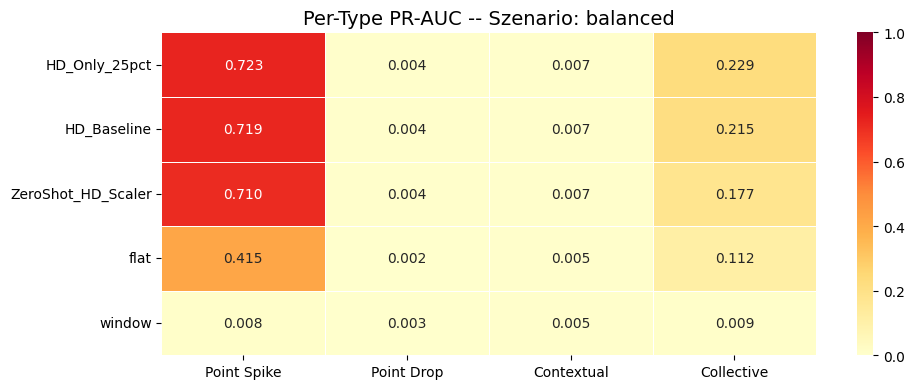

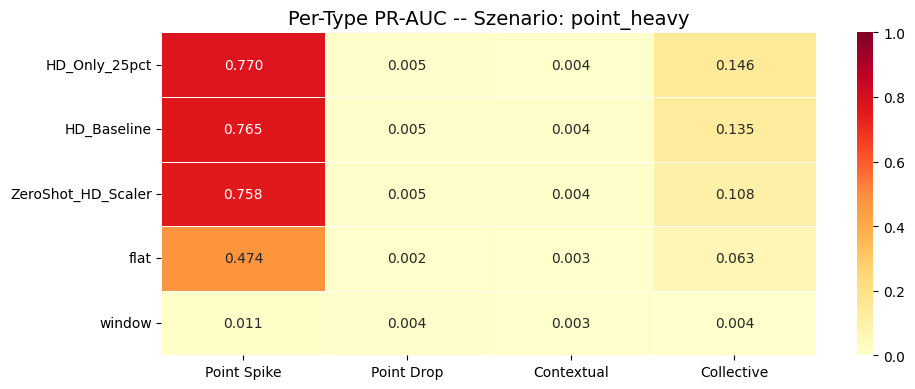

In [ ]:
# ══════════════════════════════════════════════════════════════
# 21 -- Visualisierung: Per-Type PR-AUC Heatmap
# ══════════════════════════════════════════════════════════════
for scenario in ["balanced", "point_heavy"]:
    sub = results_df[results_df["Scenario"] == scenario].copy()
    if len(sub) == 0:
        continue

    type_cols = ["PR_point_spike", "PR_point_drop", "PR_contextual", "PR_collective"]
    heatmap_data = sub.set_index("Model")[type_cols].astype(float)
    heatmap_data.columns = [c.replace("PR_", "").replace("_", " ").title() for c in type_cols]

    fig, ax = plt.subplots(figsize=(10, max(4, len(sub) * 0.8)))
    sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlOrRd",
                vmin=0, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(f"Per-Type PR-AUC -- Szenario: {scenario}", fontsize=14)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{RUN_NAME}_heatmap_{scenario}.png", dpi=150, bbox_inches='tight')
    plt.show()

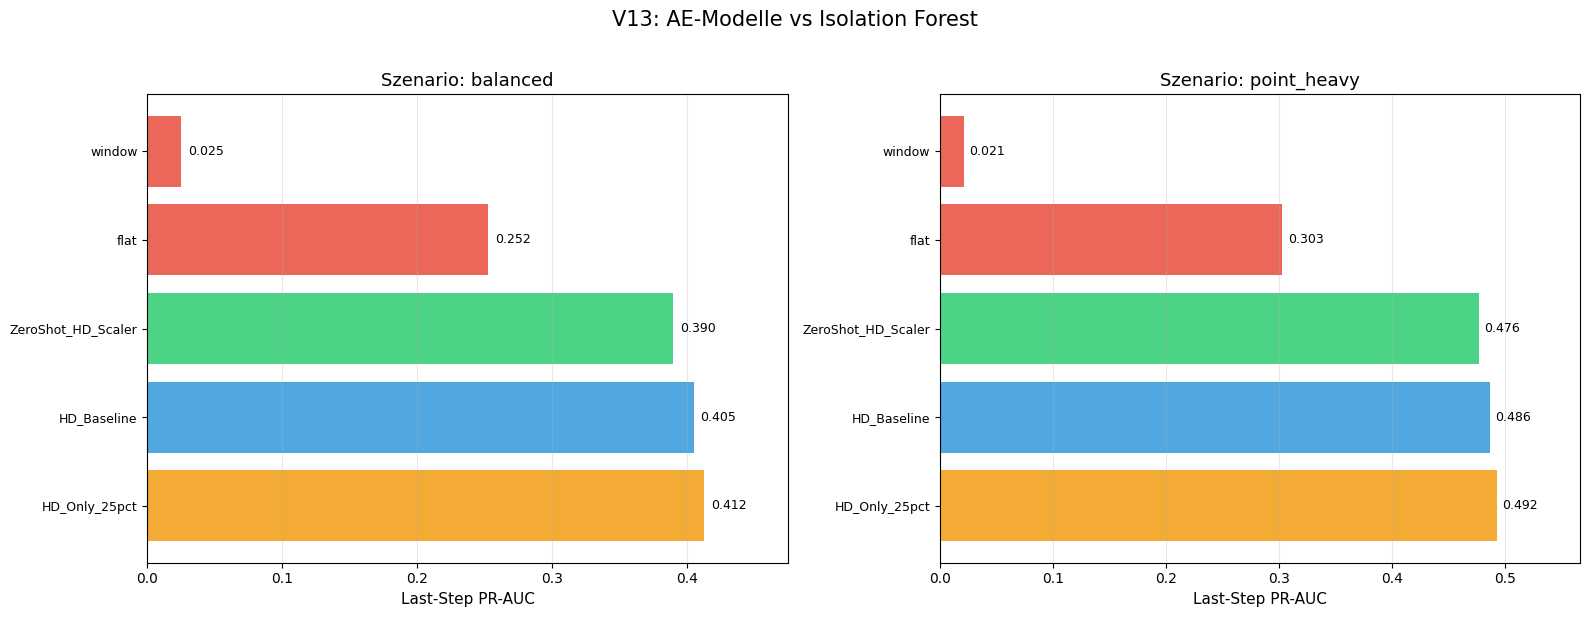

In [ ]:
# ══════════════════════════════════════════════════════════════
# 22 -- Visualisierung: AE vs iForest Vergleich
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, scenario in enumerate(["balanced", "point_heavy"]):
    ax = axes[ax_idx]
    sub = results_df[results_df["Scenario"] == scenario].copy()

    if len(sub) == 0:
        continue

    models = sub["Model"].tolist()
    ls_pr = sub["LS_PR-AUC"].astype(float).values

    colors = []
    for m in models:
        if "iForest" in sub[sub["Model"] == m]["Method"].values[0]:
            colors.append("#e74c3c")
        elif "ZeroShot" in m:
            colors.append("#2ecc71")
        elif "25pct" in m:
            colors.append("#f39c12")
        else:
            colors.append("#3498db")

    bars = ax.barh(range(len(models)), ls_pr, color=colors, alpha=0.85)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=9)
    ax.set_xlabel("Last-Step PR-AUC", fontsize=11)
    ax.set_title(f"Szenario: {scenario}", fontsize=13)
    ax.set_xlim(0, max(ls_pr) * 1.15 if len(ls_pr) > 0 else 1)
    ax.grid(True, alpha=0.3, axis='x')

    for bar, val in zip(bars, ls_pr):
        if not np.isnan(val):
            ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                    f"{val:.3f}", va='center', fontsize=9)

plt.suptitle("V13: AE-Modelle vs Isolation Forest", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/{RUN_NAME}_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

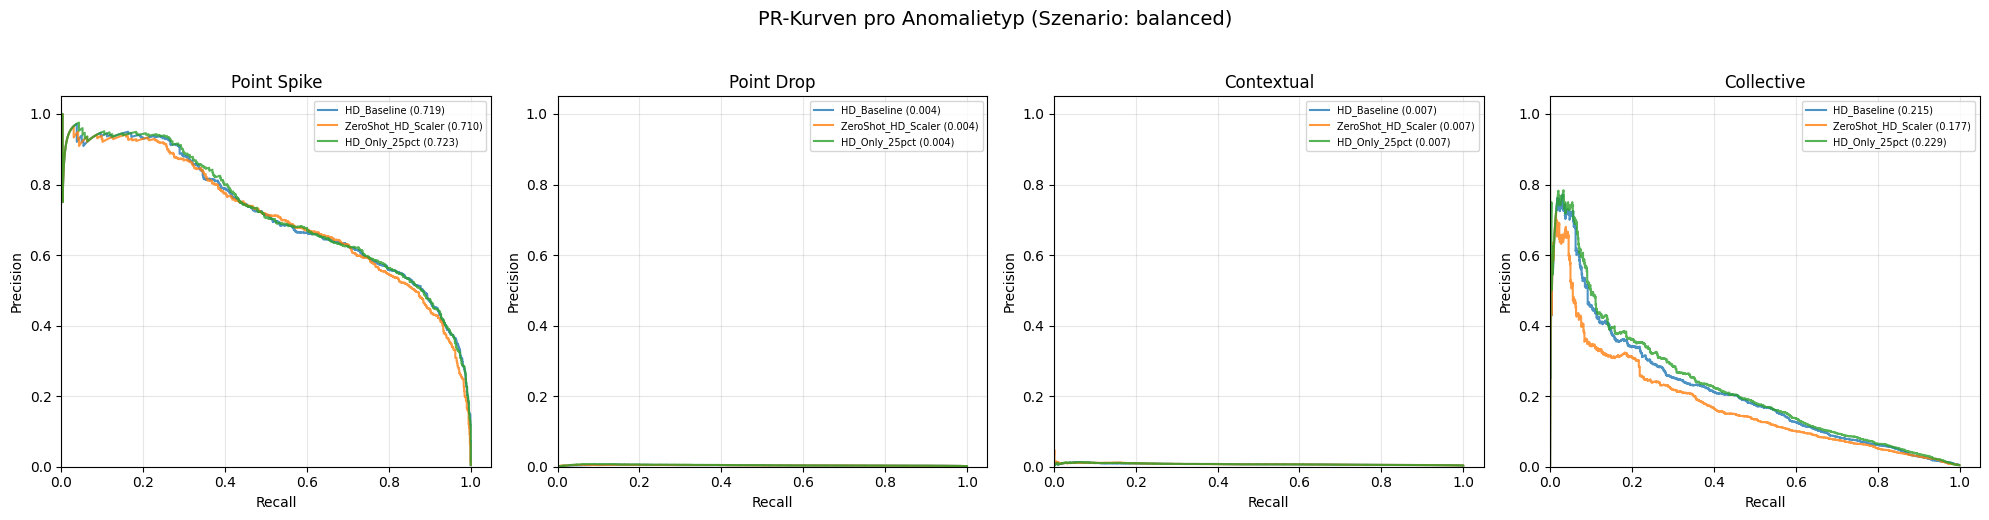

In [ ]:
# ══════════════════════════════════════════════════════════════
# 23 -- Visualisierung: PR-Kurven pro Anomalietyp (balanced Szenario)
# ══════════════════════════════════════════════════════════════
scenario = "balanced"
types = ["point_spike", "point_drop", "contextual", "collective"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for t_idx, atype in enumerate(types):
    ax = axes[t_idx]

    for name, res in all_results.items():
        if scenario not in name or not res or "meta" not in res:
            continue

        test_meta = res["meta"]
        type_mask   = test_meta["synth_type"] == atype
        normal_mask = test_meta["synth_label"] == 0
        sub = test_meta[type_mask | normal_mask]

        if len(sub) == 0 or type_mask.sum() == 0:
            continue

        y_t = (sub["synth_type"] == atype).astype(int).values
        y_s = sub["ae_score_raw"].values

        if len(np.unique(y_t)) > 1:
            prec, rec, _ = precision_recall_curve(y_t, y_s)
            pr_auc = average_precision_score(y_t, y_s)

            label_short = name.replace(f"AE__{scenario}__", "").replace(f"iForest__{scenario}__", "iF_")
            ax.plot(rec, prec, label=f"{label_short} ({pr_auc:.3f})", alpha=0.8)

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(atype.replace("_", " ").title())
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)

plt.suptitle(f"PR-Kurven pro Anomalietyp (Szenario: {scenario})", fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/{RUN_NAME}_pr_curves_per_type.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
# 24 -- Zusammenfassung
# ══════════════════════════════════════════════════════════════
summary = {
    "run_name": RUN_NAME,
    "config_base": asdict(cfg),
    "injection_scenarios": INJECTION_SCENARIOS,
    "results": {
        k: {key: val for key, val in v.items() if key != "meta"}
        for k, v in all_results.items() if v
    },
}

with open(f"{RESULTS_DIR}/{RUN_NAME}_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("="*70)
print("  V13 ABGESCHLOSSEN")
print("="*70)
print(f"  Ergebnisse: {RESULTS_DIR}/")
print(f"    {RUN_NAME}_results.csv")
print(f"    {RUN_NAME}_heatmap_balanced.png")
print(f"    {RUN_NAME}_heatmap_point_heavy.png")
print(f"    {RUN_NAME}_comparison.png")
print(f"    {RUN_NAME}_pr_curves_per_type.png")
print(f"    {RUN_NAME}_summary.json")

  V13 ABGESCHLOSSEN
  Ergebnisse: /content/drive/MyDrive/BA_Colab/data/v13_fair_eval/
    v13_fair_eval_results.csv
    v13_fair_eval_heatmap_balanced.png
    v13_fair_eval_heatmap_point_heavy.png
    v13_fair_eval_comparison.png
    v13_fair_eval_pr_curves_per_type.png
    v13_fair_eval_summary.json


Point Drop und contextuell quasi 0 DR!!

In [ ]:
# ══════════════════════════════════════════════════════════════
# V13.1 -- Helper: directional Score + iForest Aggregation
# Ganz unten unter V13 einfuegen
# ══════════════════════════════════════════════════════════════
from sklearn.ensemble import IsolationForest

def compute_ae_scores_from_predictions_v131(
    X_true: np.ndarray,
    X_pred: np.ndarray,
    input_features: List[str],
    target_features: List[str],
    score_features: Optional[List[str]] = None,
    score_mode: str = "last_step_mean",
    weighted_alpha_last: float = 0.70,
    directional_rel_weight: float = 0.70,
    directional_abs_weight: float = 0.30,
    eps: float = 1e-6,
) -> np.ndarray:
    """
    Erweiterung von V13 um score_mode='directional'.

    Idee:
    - last_step_mean: absoluter Fehler am letzten Schritt
    - window_mean: Mittelwert ueber das ganze Fenster
    - weighted_blend: Fenster + letzter Schritt
    - directional: relative + absolute Fehler am letzten Schritt,
                   damit auch starke Drops besser sichtbar werden
    """
    feature_to_idx = {f: i for i, f in enumerate(input_features)}

    if score_features is None:
        score_features = target_features

    score_idx = [feature_to_idx[f] for f in score_features]

    X_t = X_true[:, :, score_idx]
    X_p = X_pred[:, :, score_idx]

    abs_err = np.abs(X_t - X_p)

    if score_mode == "last_step_mean":
        return abs_err[:, -1, :].mean(axis=1)

    elif score_mode == "window_mean":
        return abs_err.mean(axis=(1, 2))

    elif score_mode == "weighted_blend":
        s_last = abs_err[:, -1, :].mean(axis=1)
        s_win  = abs_err.mean(axis=(1, 2))
        return weighted_alpha_last * s_last + (1.0 - weighted_alpha_last) * s_win

    elif score_mode == "directional":
        # Nur letzter Schritt: robust fuer point anomalies
        x_t = X_t[:, -1, :]
        x_p = X_p[:, -1, :]

        abs_last = np.abs(x_t - x_p)

        # symmetrisch relativer Fehler -> betont auch Drops
        denom = np.maximum(np.maximum(np.abs(x_t), np.abs(x_p)), eps)
        rel_last = abs_last / denom

        score_abs = abs_last.mean(axis=1)
        score_rel = rel_last.mean(axis=1)

        return directional_rel_weight * score_rel + directional_abs_weight * score_abs

    else:
        raise ValueError(f"Unbekannter score_mode: {score_mode}")


def build_iforest_agg_features_from_sequences(
    X: np.ndarray,
    feature_names: List[str],
    base_features: Optional[List[str]] = None,
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Baut kompakte Window-Features fuer iForest statt Flattening.
    Standardmaessig nur auf den Demand-/Zeit-Features des Fensters.
    """
    if base_features is None:
        base_features = feature_names

    feat_to_idx = {f: i for i, f in enumerate(feature_names)}
    idx = [feat_to_idx[f] for f in base_features]

    rows = {}
    for f, j in zip(base_features, idx):
        arr = X[:, :, j]

        rows[f"{f}__last"]  = arr[:, -1]
        rows[f"{f}__mean"]  = arr.mean(axis=1)
        rows[f"{f}__std"]   = arr.std(axis=1)
        rows[f"{f}__min"]   = arr.min(axis=1)
        rows[f"{f}__max"]   = arr.max(axis=1)
        rows[f"{f}__delta"] = arr[:, -1] - arr[:, 0]

    # Zusatzfeatures speziell fuer Nachfrage
    if "n_lends" in feat_to_idx and "n_returns" in feat_to_idx:
        lends = X[:, :, feat_to_idx["n_lends"]]
        rets  = X[:, :, feat_to_idx["n_returns"]]

        total = lends + rets
        rows["total_demand__last"]  = total[:, -1]
        rows["total_demand__mean"]  = total.mean(axis=1)
        rows["total_demand__std"]   = total.std(axis=1)
        rows["total_demand__max"]   = total.max(axis=1)
        rows["total_demand__delta"] = total[:, -1] - total[:, 0]

        ratio_last = (lends[:, -1] + 1.0) / (rets[:, -1] + 1.0)
        rows["lend_return_ratio__last"] = ratio_last

    df_feat = pd.DataFrame(rows)
    return df_feat, list(df_feat.columns)

In [ ]:
# ══════════════════════════════════════════════════════════════
# V13.1 -- Evaluation: AE mit directional + iForest mit Val-Threshold
# Direkt unter die vorherige V13.1-Helper-Cell
# ══════════════════════════════════════════════════════════════
def evaluate_against_synthetic_v131_ae(
    model,
    df_injected: pd.DataFrame,
    scaler: StandardScaler,
    cfg,
    val_start: pd.Timestamp,
    test_start: pd.Timestamp,
    experiment_name: str,
    score_mode: str = "directional",
    verbose: bool = True
) -> Dict:
    """
    Wie V13, aber mit erweitertem AE-Scoring (inkl. directional).
    Threshold wird auf VAL gesetzt.
    """
    ae_features        = cfg.ae_features
    ae_target_features = cfg.ae_target_features if cfg.ae_target_features is not None else cfg.ae_features

    df_ae = df_injected.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    df_ae = df_ae.dropna(subset=ae_features).copy()

    df_ae_scaled = df_ae.copy()
    df_ae_scaled[ae_features] = scaler.transform(df_ae[ae_features])

    for col in ["synth_label", "synth_type", "original_n_lends", "original_n_returns"]:
        if col in df_ae.columns:
            df_ae_scaled[col] = df_ae[col].values

    X_all, meta_all = make_sequences_with_window_labels(
        df_ae_scaled,
        feature_cols=ae_features,
        window_size=cfg.ae_window_size,
        synth_label_col="synth_label",
        synth_type_col="synth_type",
        require_contiguous=cfg.require_contiguous,
        agg_minutes=cfg.aggregation_minutes
    )

    meta_all["split_eval"] = np.where(
        meta_all["hour_ts"] < val_start, "train",
        np.where(meta_all["hour_ts"] < test_start, "val", "test")
    )

    X_hat_all = predict_in_batches(model, X_all, batch_size=cfg.eval_batch_size)
    all_scores = compute_ae_scores_from_predictions_v131(
        X_true=X_all,
        X_pred=X_hat_all,
        input_features=ae_features,
        target_features=ae_target_features,
        score_features=cfg.ae_score_features,
        score_mode=score_mode,
        weighted_alpha_last=getattr(cfg, "weighted_alpha_last", 0.70),
    )
    meta_all["ae_score_raw"] = all_scores

    val_meta  = meta_all[meta_all["split_eval"] == "val"].copy()
    test_meta = meta_all[meta_all["split_eval"] == "test"].copy()

    results = {
        "experiment": experiment_name,
        "model_family": "AE",
        "score_mode": score_mode,
        "threshold_source": "validation_best_f1_last_step",
        "n_val": len(val_meta),
        "n_test": len(test_meta),
    }

    # VAL threshold
    y_val = val_meta["synth_label"].astype(int).values
    s_val = val_meta["ae_score_raw"].values

    if len(np.unique(y_val)) > 1:
        prec_val, rec_val, thr_val = precision_recall_curve(y_val, s_val)
        results["val_pr_auc"]  = average_precision_score(y_val, s_val)
        results["val_roc_auc"] = roc_auc_score(y_val, s_val)

        if len(thr_val) > 0:
            f1_val = 2 * prec_val[:-1] * rec_val[:-1] / (prec_val[:-1] + rec_val[:-1] + 1e-10)
            k = np.argmax(f1_val)
            results["val_best_f1"]        = f1_val[k]
            results["val_best_precision"] = prec_val[k]
            results["val_best_recall"]    = rec_val[k]
            results["val_best_threshold"] = float(thr_val[k])
        else:
            results["val_best_f1"] = None
            results["val_best_threshold"] = None
    else:
        results["val_pr_auc"] = results["val_roc_auc"] = None
        results["val_best_f1"] = results["val_best_threshold"] = None

    # TEST last-step
    y_test_ls = test_meta["synth_label"].astype(int).values
    s_test    = test_meta["ae_score_raw"].values

    if len(np.unique(y_test_ls)) > 1:
        results["ls_pr_auc"]  = average_precision_score(y_test_ls, s_test)
        results["ls_roc_auc"] = roc_auc_score(y_test_ls, s_test)
    else:
        results["ls_pr_auc"] = results["ls_roc_auc"] = None

    thr = results.get("val_best_threshold")
    if thr is not None:
        y_pred_ls = (s_test >= thr).astype(int)
        results["ls_f1_at_val_threshold"]        = f1_score(y_test_ls, y_pred_ls, zero_division=0)
        results["ls_precision_at_val_threshold"] = precision_score(y_test_ls, y_pred_ls, zero_division=0)
        results["ls_recall_at_val_threshold"]    = recall_score(y_test_ls, y_pred_ls, zero_division=0)
    else:
        results["ls_f1_at_val_threshold"] = None
        results["ls_precision_at_val_threshold"] = None
        results["ls_recall_at_val_threshold"] = None

    # TEST window
    y_test_win = test_meta["window_synth_label"].astype(int).values
    if len(np.unique(y_test_win)) > 1:
        results["win_pr_auc"]  = average_precision_score(y_test_win, s_test)
        results["win_roc_auc"] = roc_auc_score(y_test_win, s_test)
        if thr is not None:
            y_pred_win = (s_test >= thr).astype(int)
            results["win_f1_at_val_threshold"] = f1_score(y_test_win, y_pred_win, zero_division=0)
        else:
            results["win_f1_at_val_threshold"] = None
    else:
        results["win_pr_auc"] = results["win_roc_auc"] = None
        results["win_f1_at_val_threshold"] = None

    # per type
    results["per_type"] = {}
    for atype in ["point_spike", "point_drop", "contextual", "collective"]:
        type_mask   = test_meta["synth_type"] == atype
        normal_mask = test_meta["synth_label"] == 0
        sub = test_meta[type_mask | normal_mask].copy()

        info = {"n": int(type_mask.sum())}
        if len(sub) == 0 or type_mask.sum() == 0:
            info.update({"pr_auc": None, "roc_auc": None, "detection_rate": None})
        else:
            y_t = (sub["synth_type"] == atype).astype(int).values
            y_s = sub["ae_score_raw"].values

            if len(np.unique(y_t)) > 1:
                info["pr_auc"]  = average_precision_score(y_t, y_s)
                info["roc_auc"] = roc_auc_score(y_t, y_s)
            else:
                info["pr_auc"] = info["roc_auc"] = None

            if thr is not None:
                type_seqs = test_meta[type_mask]
                info["detection_rate"] = float((type_seqs["ae_score_raw"] >= thr).mean()) if len(type_seqs) > 0 else None
            else:
                info["detection_rate"] = None

        results["per_type"][atype] = info

    if verbose:
        print(f"\n[{experiment_name}]")
        print(f"  score_mode={score_mode}")
        print(f"  VAL PR-AUC={results.get('val_pr_auc')}")
        print(f"  TEST LS PR-AUC={results.get('ls_pr_auc')}")
        print(f"  TEST WIN PR-AUC={results.get('win_pr_auc')}")
        if thr is not None:
            print(f"  VAL Threshold={thr:.6f} | TEST LS F1@ValThr={results['ls_f1_at_val_threshold']:.4f}")
        for atype, info in results["per_type"].items():
            pr = info["pr_auc"]
            dr = info["detection_rate"]
            pr_s = f"{pr:.4f}" if pr is not None else "N/A"
            dr_s = f"{dr:.2%}" if dr is not None else "N/A"
            print(f"  {atype:15s} n={info['n']:5d} | PR-AUC={pr_s} | DR={dr_s}")

    results["meta_test"] = test_meta
    results["meta_val"] = val_meta
    return results


def evaluate_against_synthetic_v131_iforest(
    df_clean: pd.DataFrame,
    df_injected: pd.DataFrame,
    scaler: StandardScaler,
    cfg,
    val_start: pd.Timestamp,
    test_start: pd.Timestamp,
    experiment_name: str,
    contamination: float = 0.015,
    random_state: int = 42,
    verbose: bool = True
) -> Dict:
    """
    iForest auf aggregierten Window-Features.
    Training nur auf cleanen Daten.
    Threshold auf VAL der injizierten Daten.
    """
    ae_features = cfg.ae_features

    # ---------- TRAIN auf clean ----------
    df_train = df_clean.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    df_train = df_train.dropna(subset=ae_features).copy()

    train_mask_rows = df_train["hour_ts"] < val_start
    df_train = df_train.loc[train_mask_rows].copy()

    df_train_scaled = df_train.copy()
    df_train_scaled[ae_features] = scaler.transform(df_train[ae_features])

    X_train, meta_train = make_sequences_with_window_labels(
        df_train_scaled,
        feature_cols=ae_features,
        window_size=cfg.ae_window_size,
        synth_label_col=None,
        synth_type_col=None,
        require_contiguous=cfg.require_contiguous,
        agg_minutes=cfg.aggregation_minutes
    )

    X_train_feat, if_cols = build_iforest_agg_features_from_sequences(
        X_train, feature_names=ae_features, base_features=ae_features
    )

    iforest = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1
    )
    iforest.fit(X_train_feat)

    # ---------- VAL/TEST auf injected ----------
    df_eval = df_injected.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    df_eval = df_eval.dropna(subset=ae_features).copy()

    df_eval_scaled = df_eval.copy()
    df_eval_scaled[ae_features] = scaler.transform(df_eval[ae_features])

    for col in ["synth_label", "synth_type", "original_n_lends", "original_n_returns"]:
        if col in df_eval.columns:
            df_eval_scaled[col] = df_eval[col].values

    X_eval, meta_eval = make_sequences_with_window_labels(
        df_eval_scaled,
        feature_cols=ae_features,
        window_size=cfg.ae_window_size,
        synth_label_col="synth_label",
        synth_type_col="synth_type",
        require_contiguous=cfg.require_contiguous,
        agg_minutes=cfg.aggregation_minutes
    )
    X_eval_feat, _ = build_iforest_agg_features_from_sequences(
        X_eval, feature_names=ae_features, base_features=ae_features
    )

    meta_eval["if_score_raw"] = -iforest.score_samples(X_eval_feat)  # hoeher = anomaler
    meta_eval["split_eval"] = np.where(
        meta_eval["hour_ts"] < val_start, "train",
        np.where(meta_eval["hour_ts"] < test_start, "val", "test")
    )

    val_meta  = meta_eval[meta_eval["split_eval"] == "val"].copy()
    test_meta = meta_eval[meta_eval["split_eval"] == "test"].copy()

    results = {
        "experiment": experiment_name,
        "model_family": "iForestAgg",
        "score_mode": "iforest_agg",
        "threshold_source": "validation_best_f1_last_step",
        "n_val": len(val_meta),
        "n_test": len(test_meta),
        "iforest_feature_count": len(if_cols),
    }

    # VAL threshold
    y_val = val_meta["synth_label"].astype(int).values
    s_val = val_meta["if_score_raw"].values

    if len(np.unique(y_val)) > 1:
        prec_val, rec_val, thr_val = precision_recall_curve(y_val, s_val)
        results["val_pr_auc"]  = average_precision_score(y_val, s_val)
        results["val_roc_auc"] = roc_auc_score(y_val, s_val)

        if len(thr_val) > 0:
            f1_val = 2 * prec_val[:-1] * rec_val[:-1] / (prec_val[:-1] + rec_val[:-1] + 1e-10)
            k = np.argmax(f1_val)
            results["val_best_f1"]        = f1_val[k]
            results["val_best_precision"] = prec_val[k]
            results["val_best_recall"]    = rec_val[k]
            results["val_best_threshold"] = float(thr_val[k])
        else:
            results["val_best_f1"] = None
            results["val_best_threshold"] = None
    else:
        results["val_pr_auc"] = results["val_roc_auc"] = None
        results["val_best_f1"] = results["val_best_threshold"] = None

    # TEST last-step
    y_test_ls = test_meta["synth_label"].astype(int).values
    s_test    = test_meta["if_score_raw"].values

    if len(np.unique(y_test_ls)) > 1:
        results["ls_pr_auc"]  = average_precision_score(y_test_ls, s_test)
        results["ls_roc_auc"] = roc_auc_score(y_test_ls, s_test)
    else:
        results["ls_pr_auc"] = results["ls_roc_auc"] = None

    thr = results.get("val_best_threshold")
    if thr is not None:
        y_pred_ls = (s_test >= thr).astype(int)
        results["ls_f1_at_val_threshold"]        = f1_score(y_test_ls, y_pred_ls, zero_division=0)
        results["ls_precision_at_val_threshold"] = precision_score(y_test_ls, y_pred_ls, zero_division=0)
        results["ls_recall_at_val_threshold"]    = recall_score(y_test_ls, y_pred_ls, zero_division=0)
    else:
        results["ls_f1_at_val_threshold"] = None
        results["ls_precision_at_val_threshold"] = None
        results["ls_recall_at_val_threshold"] = None

    # TEST window
    y_test_win = test_meta["window_synth_label"].astype(int).values
    if len(np.unique(y_test_win)) > 1:
        results["win_pr_auc"]  = average_precision_score(y_test_win, s_test)
        results["win_roc_auc"] = roc_auc_score(y_test_win, s_test)
        if thr is not None:
            y_pred_win = (s_test >= thr).astype(int)
            results["win_f1_at_val_threshold"] = f1_score(y_test_win, y_pred_win, zero_division=0)
        else:
            results["win_f1_at_val_threshold"] = None
    else:
        results["win_pr_auc"] = results["win_roc_auc"] = None
        results["win_f1_at_val_threshold"] = None

    # per type
    results["per_type"] = {}
    for atype in ["point_spike", "point_drop", "contextual", "collective"]:
        type_mask   = test_meta["synth_type"] == atype
        normal_mask = test_meta["synth_label"] == 0
        sub = test_meta[type_mask | normal_mask].copy()

        info = {"n": int(type_mask.sum())}
        if len(sub) == 0 or type_mask.sum() == 0:
            info.update({"pr_auc": None, "roc_auc": None, "detection_rate": None})
        else:
            y_t = (sub["synth_type"] == atype).astype(int).values
            y_s = sub["if_score_raw"].values

            if len(np.unique(y_t)) > 1:
                info["pr_auc"]  = average_precision_score(y_t, y_s)
                info["roc_auc"] = roc_auc_score(y_t, y_s)
            else:
                info["pr_auc"] = info["roc_auc"] = None

            if thr is not None:
                type_seqs = test_meta[type_mask]
                info["detection_rate"] = float((type_seqs["if_score_raw"] >= thr).mean()) if len(type_seqs) > 0 else None
            else:
                info["detection_rate"] = None

        results["per_type"][atype] = info

    if verbose:
        print(f"\n[{experiment_name}]")
        print(f"  iforest_feature_count={len(if_cols)}")
        print(f"  VAL PR-AUC={results.get('val_pr_auc')}")
        print(f"  TEST LS PR-AUC={results.get('ls_pr_auc')}")
        print(f"  TEST WIN PR-AUC={results.get('win_pr_auc')}")
        if thr is not None:
            print(f"  VAL Threshold={thr:.6f} | TEST LS F1@ValThr={results['ls_f1_at_val_threshold']:.4f}")
        for atype, info in results["per_type"].items():
            pr = info["pr_auc"]
            dr = info["detection_rate"]
            pr_s = f"{pr:.4f}" if pr is not None else "N/A"
            dr_s = f"{dr:.2%}" if dr is not None else "N/A"
            print(f"  {atype:15s} n={info['n']:5d} | PR-AUC={pr_s} | DR={dr_s}")

    results["meta_test"] = test_meta
    results["meta_val"] = val_meta
    return results

In [ ]:
# ══════════════════════════════════════════════════════════════
# V13.1 -- Zusatzexperimente: AE directional + iForestAgg
# Direkt unter die vorherige Cell
# Voraussetzung:
# - ae_models existiert aus V13
# - df_hd_inj_balanced und df_hd_inj_point_heavy existieren aus V13
# - df_hd, scaler_hd, cfg, train_end_hd, val_end_hd, RESULTS_DIR, RUN_NAME existieren
# ══════════════════════════════════════════════════════════════
all_results_v131 = {}

scenario_map_v131 = {
    "balanced": df_hd_inj_balanced,
}

# 1) AE directional fuer bestehende AE-Modelle
for scenario_name, df_inj in scenario_map_v131.items():
    print(f"\n{'='*90}")
    print(f"V13.1 -- AE directional -- Szenario: {scenario_name}")
    print(f"{'='*90}")

    for model_name, (model_obj, scaler_obj) in ae_models.items():
        exp_name = f"AE_directional__{scenario_name}__{model_name}"
        res = evaluate_against_synthetic_v131_ae(
            model=model_obj,
            df_injected=df_inj,
            scaler=scaler_obj,
            cfg=cfg,
            val_start=train_end_hd,
            test_start=val_end_hd,
            experiment_name=exp_name,
            score_mode="directional",
            verbose=True
        )
        all_results_v131[exp_name] = res

# 2) iForest mit aggregierten Window-Features
for scenario_name, df_inj in scenario_map_v131.items():
    print(f"\n{'='*90}")
    print(f"V13.1 -- iForestAgg -- Szenario: {scenario_name}")
    print(f"{'='*90}")

    exp_name = f"iForestAgg__{scenario_name}__HD_Local"
    res = evaluate_against_synthetic_v131_iforest(
        df_clean=df_hd,
        df_injected=df_inj,
        scaler=scaler_hd,
        cfg=cfg,
        val_start=train_end_hd,
        test_start=val_end_hd,
        experiment_name=exp_name,
        contamination=0.015,
        random_state=42,
        verbose=True
    )
    all_results_v131[exp_name] = res

print("\nV13.1 Zusatzexperimente abgeschlossen.")


V13.1 -- AE directional -- Szenario: balanced

[AE_directional__balanced__HD_Baseline]
  score_mode=directional
  VAL PR-AUC=0.40811501155538726
  TEST LS PR-AUC=0.40969285939931854
  TEST WIN PR-AUC=0.3651251273089046
  VAL Threshold=1.642373 | TEST LS F1@ValThr=0.4388
  point_spike     n=  924 | PR-AUC=0.7749 | DR=78.68%
  point_drop      n=  351 | PR-AUC=0.0089 | DR=0.28%
  contextual      n=  718 | PR-AUC=0.0101 | DR=0.97%
  collective      n=  881 | PR-AUC=0.1852 | DR=19.86%

[AE_directional__balanced__ZeroShot_HD_Scaler]
  score_mode=directional
  VAL PR-AUC=0.3996501600991393
  TEST LS PR-AUC=0.3894773724401815
  TEST WIN PR-AUC=0.3662493082793889
  VAL Threshold=1.573785 | TEST LS F1@ValThr=0.4133
  point_spike     n=  924 | PR-AUC=0.7417 | DR=78.46%
  point_drop      n=  351 | PR-AUC=0.0095 | DR=0.85%
  contextual      n=  718 | PR-AUC=0.0109 | DR=1.25%
  collective      n=  881 | PR-AUC=0.1385 | DR=17.03%

[AE_directional__balanced__HD_Only_25pct]
  score_mode=directional
  

KeyError: None

In [ ]:
# ══════════════════════════════════════════════════════════════
# V13.1 -- Ergebnistabelle
# Direkt unter die V13.1-Experiment-Cell
# ══════════════════════════════════════════════════════════════
rows_v131 = []
for name, res in all_results_v131.items():
    if not res:
        continue

    parts = name.split("__")
    method = parts[0] if len(parts) > 0 else "?"
    scenario = parts[1] if len(parts) > 1 else "?"
    model_name = parts[2] if len(parts) > 2 else "?"

    row = {
        "Method": method,
        "Scenario": scenario,
        "Model": model_name,
        "Experiment": name,
        "VAL_PR-AUC": res.get("val_pr_auc"),
        "VAL_Best_F1": res.get("val_best_f1"),
        "VAL_Threshold": res.get("val_best_threshold"),
        "LS_PR-AUC": res.get("ls_pr_auc"),
        "LS_ROC-AUC": res.get("ls_roc_auc"),
        "LS_F1@ValThr": res.get("ls_f1_at_val_threshold"),
        "Win_PR-AUC": res.get("win_pr_auc"),
        "Win_F1@ValThr": res.get("win_f1_at_val_threshold"),
        "Score_Mode": res.get("score_mode"),
    }

    for atype in ["point_spike", "point_drop", "contextual", "collective"]:
        info = res.get("per_type", {}).get(atype, {})
        row[f"PR_{atype}"] = info.get("pr_auc")
        row[f"DR_{atype}"] = info.get("detection_rate")

    rows_v131.append(row)

results_v131_df = pd.DataFrame(rows_v131).sort_values(
    ["Scenario", "LS_PR-AUC"], ascending=[True, False]
).reset_index(drop=True)

print("="*130)
print("  V13.1 ERGEBNISSE -- AE directional + iForestAgg")
print("="*130)

main_cols = [
    "Scenario", "Method", "Model", "Score_Mode",
    "VAL_PR-AUC", "VAL_Best_F1", "VAL_Threshold",
    "LS_PR-AUC", "LS_F1@ValThr",
    "Win_PR-AUC", "Win_F1@ValThr"
]
print("\n--- Hauptmetriken ---")
print(results_v131_df[main_cols].to_string(index=False, float_format="{:.4f}".format))

type_cols = [
    "Scenario", "Method", "Model",
    "PR_point_spike", "PR_point_drop", "PR_contextual", "PR_collective"
]
print("\n--- Per-Type PR-AUC ---")
print(results_v131_df[type_cols].to_string(index=False, float_format="{:.4f}".format))

results_v131_path = f"{RESULTS_DIR}/{RUN_NAME}_v131_results.csv"
results_v131_df.to_csv(results_v131_path, index=False)
print(f"\nGespeichert: {results_v131_path}")

  V13.1 ERGEBNISSE -- AE directional + iForestAgg

--- Hauptmetriken ---
Scenario         Method              Model  Score_Mode  VAL_PR-AUC  VAL_Best_F1  VAL_Threshold  LS_PR-AUC  LS_F1@ValThr  Win_PR-AUC  Win_F1@ValThr
balanced AE_directional      HD_Only_25pct directional      0.4276       0.4664         1.6321     0.4214        0.4586      0.3689         0.0450
balanced AE_directional        HD_Baseline directional      0.4081       0.4482         1.6424     0.4097        0.4388      0.3651         0.0430
balanced AE_directional ZeroShot_HD_Scaler directional      0.3997       0.4330         1.5738     0.3895        0.4133      0.3662         0.0459

--- Per-Type PR-AUC ---
Scenario         Method              Model  PR_point_spike  PR_point_drop  PR_contextual  PR_collective
balanced AE_directional      HD_Only_25pct          0.7828         0.0094         0.0095         0.2090
balanced AE_directional        HD_Baseline          0.7749         0.0089         0.0101         0.1852
ba

In [ ]:
# ══════════════════════════════════════════════════════════════
# Optional -- V13 und V13.1 zusammenfassen
# Ganz unten optional
# ══════════════════════════════════════════════════════════════
results_v13_comp = results_df.copy()
results_v13_comp["Source"] = "V13"

results_v131_comp = results_v131_df.copy()
results_v131_comp["Source"] = "V13.1"

common_cols = sorted(set(results_v13_comp.columns).intersection(results_v131_comp.columns))
combined_comp = pd.concat(
    [results_v13_comp[common_cols + ["Source"]], results_v131_comp[common_cols + ["Source"]]],
    ignore_index=True
)

print("="*130)
print("  V13 vs V13.1 -- Vergleich")
print("="*130)
show_cols = [c for c in [
    "Source", "Scenario", "Method", "Model", "Score_Mode",
    "VAL_PR-AUC", "LS_PR-AUC", "LS_F1@ValThr",
    "PR_point_spike", "PR_point_drop", "PR_contextual", "PR_collective"
] if c in combined_comp.columns]
print(combined_comp[show_cols].to_string(index=False, float_format="{:.4f}".format))

  V13 vs V13.1 -- Vergleich
Source Source    Scenario         Method              Model  VAL_PR-AUC  LS_PR-AUC  LS_F1@ValThr  PR_point_spike  PR_point_drop  PR_contextual  PR_collective
   V13    V13    balanced             AE      HD_Only_25pct      0.4201     0.4125        0.4624          0.7232         0.0044         0.0073         0.2289
   V13    V13    balanced             AE        HD_Baseline      0.4152     0.4048        0.4556          0.7189         0.0040         0.0072         0.2152
   V13    V13    balanced             AE ZeroShot_HD_Scaler      0.4053     0.3898        0.4462          0.7104         0.0040         0.0074         0.1775
   V13    V13    balanced        iForest               flat         NaN     0.2524           NaN          0.4149         0.0016         0.0045         0.1121
   V13    V13    balanced        iForest             window         NaN     0.0248           NaN          0.0083         0.0032         0.0051         0.0092
   V13    V13 point_heav

Etwas besser aber noch schlecht!!

In [ ]:
# ══════════════════════════════════════════════════════════════
# V13.2 -- Statistik-Pipeline Helper
# Direkt unter V13.1 einfuegen
# ══════════════════════════════════════════════════════════════
from scipy.stats import poisson

def build_statistical_reference_profiles(
    df_clean: pd.DataFrame,
    train_end: pd.Timestamp,
    station_col: str = "station_id",
    time_col: str = "hour_ts",
    lends_col: str = "n_lends",
    returns_col: str = "n_returns",
) -> Dict[str, pd.DataFrame]:
    """
    Baut Erwartungsprofile nur auf Trainingsdaten:
    - station x hour_of_day x day_of_week
    - fallback station x hour_of_day
    - fallback global hour_of_day x day_of_week
    """
    x = df_clean.copy()
    x = x[x[time_col] < train_end].copy()
    x["hour"] = x[time_col].dt.hour
    x["dow"] = x[time_col].dt.dayofweek
    x["total_demand"] = x[lends_col] + x[returns_col]

    agg_map = {
        lends_col: ["mean", "std", "median"],
        returns_col: ["mean", "std", "median"],
        "total_demand": ["mean", "std", "median"],
    }

    prof_station_hod_dow = (
        x.groupby([station_col, "hour", "dow"], observed=True)
         .agg(agg_map)
         .reset_index()
    )
    prof_station_hod_dow.columns = [
        station_col, "hour", "dow",
        "exp_lends_mean", "exp_lends_std", "exp_lends_median",
        "exp_returns_mean", "exp_returns_std", "exp_returns_median",
        "exp_total_mean", "exp_total_std", "exp_total_median"
    ]

    prof_station_hod = (
        x.groupby([station_col, "hour"], observed=True)
         .agg(agg_map)
         .reset_index()
    )
    prof_station_hod.columns = [
        station_col, "hour",
        "fb1_lends_mean", "fb1_lends_std", "fb1_lends_median",
        "fb1_returns_mean", "fb1_returns_std", "fb1_returns_median",
        "fb1_total_mean", "fb1_total_std", "fb1_total_median"
    ]

    prof_global_hod_dow = (
        x.groupby(["hour", "dow"], observed=True)
         .agg(agg_map)
         .reset_index()
    )
    prof_global_hod_dow.columns = [
        "hour", "dow",
        "fb2_lends_mean", "fb2_lends_std", "fb2_lends_median",
        "fb2_returns_mean", "fb2_returns_std", "fb2_returns_median",
        "fb2_total_mean", "fb2_total_std", "fb2_total_median"
    ]

    return {
        "station_hod_dow": prof_station_hod_dow,
        "station_hod": prof_station_hod,
        "global_hod_dow": prof_global_hod_dow,
    }


def attach_statistical_expectations(
    df: pd.DataFrame,
    ref_profiles: Dict[str, pd.DataFrame],
    station_col: str = "station_id",
    time_col: str = "hour_ts",
    lends_col: str = "n_lends",
    returns_col: str = "n_returns",
) -> pd.DataFrame:
    """
    Fuegt Erwartungswerte/Std mit Fallback-Logik an:
    1) station x hour x dow
    2) station x hour
    3) global hour x dow
    """
    x = df.copy()
    x["hour"] = x[time_col].dt.hour
    x["dow"] = x[time_col].dt.dayofweek
    x["total_demand"] = x[lends_col] + x[returns_col]

    x = x.merge(
        ref_profiles["station_hod_dow"],
        on=[station_col, "hour", "dow"],
        how="left"
    )
    x = x.merge(
        ref_profiles["station_hod"],
        on=[station_col, "hour"],
        how="left"
    )
    x = x.merge(
        ref_profiles["global_hod_dow"],
        on=["hour", "dow"],
        how="left"
    )

    for base in ["lends", "returns", "total"]:
        x[f"exp_{base}_mean_final"] = (
            x[f"exp_{base}_mean"]
            .fillna(x[f"fb1_{base}_mean"])
            .fillna(x[f"fb2_{base}_mean"])
        )
        x[f"exp_{base}_std_final"] = (
            x[f"exp_{base}_std"]
            .fillna(x[f"fb1_{base}_std"])
            .fillna(x[f"fb2_{base}_std"])
            .fillna(0.0)
        )
        x[f"exp_{base}_median_final"] = (
            x[f"exp_{base}_median"]
            .fillna(x[f"fb1_{base}_median"])
            .fillna(x[f"fb2_{base}_median"])
        )

    return x


def compute_statistical_scores(
    df_with_exp: pd.DataFrame,
    lends_col: str = "n_lends",
    returns_col: str = "n_returns",
    eps: float = 1e-6,
    z_cap: float = 10.0,
) -> pd.DataFrame:
    """
    Erzeugt mehrere statistische Scores:
    - z_total / z_lends / z_returns
    - poisson surprisal fuer total_demand
    - signed residuals
    """
    x = df_with_exp.copy()
    x["total_demand"] = x[lends_col] + x[returns_col]

    def safe_z(obs, mu, sigma):
        sigma_eff = np.maximum(sigma, 1.0)
        z = (obs - mu) / sigma_eff
        return np.clip(z, -z_cap, z_cap)

    x["z_total_signed"] = safe_z(
        x["total_demand"].values,
        x["exp_total_mean_final"].values,
        x["exp_total_std_final"].values
    )
    x["z_total_abs"] = np.abs(x["z_total_signed"])

    x["z_lends_signed"] = safe_z(
        x[lends_col].values,
        x["exp_lends_mean_final"].values,
        x["exp_lends_std_final"].values
    )
    x["z_returns_signed"] = safe_z(
        x[returns_col].values,
        x["exp_returns_mean_final"].values,
        x["exp_returns_std_final"].values
    )
    x["z_lr_abs_mean"] = (np.abs(x["z_lends_signed"]) + np.abs(x["z_returns_signed"])) / 2.0

    # Richtungssensitive Scores
    x["drop_score"]  = np.maximum(-x["z_total_signed"], 0.0)
    x["spike_score"] = np.maximum(x["z_total_signed"], 0.0)

    # Poisson-Surprisal auf total demand
    lam = np.maximum(x["exp_total_mean_final"].values, 0.1)
    obs = np.maximum(x["total_demand"].round().astype(int).values, 0)

    # Zwei-seitige tail probability approximiert ueber survival/cdf
    cdf_vals = poisson.cdf(obs, lam)
    sf_vals  = poisson.sf(obs - 1, lam)
    tail_prob = 2.0 * np.minimum(cdf_vals, sf_vals)
    tail_prob = np.clip(tail_prob, 1e-12, 1.0)
    x["poisson_surprisal"] = -np.log(tail_prob)

    # Hauptscore fuer "allgemeine" statistische Anomalie
    x["stat_score_raw"] = 0.50 * x["z_total_abs"] + 0.30 * x["z_lr_abs_mean"] + 0.20 * x["poisson_surprisal"]

    return x

In [ ]:
# ══════════════════════════════════════════════════════════════
# V13.2 -- Statistik-Pipeline Evaluation mit VAL-Threshold (FIX)
# Ersetzt die vorherige statx2-Cell komplett
# ══════════════════════════════════════════════════════════════
def build_statistical_sequence_meta(
    df_scored: pd.DataFrame,
    cfg,
    val_start: pd.Timestamp,
    test_start: pd.Timestamp,
    score_col: str = "stat_score_raw",
) -> pd.DataFrame:
    """
    Baut Sequenz-Meta analog zur AE-Logik und mappt den letzten Zeitschritt-Score
    auf jede Sequenz.
    FIX:
    - entfernt potenziell vorhandene score_col-Spalten vor dem Merge
    - behandelt _x/_y-Kollisionen robust
    """
    x = df_scored.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

    seq_base = x.dropna(subset=cfg.ae_features).copy()

    _, meta_seq = make_sequences_with_window_labels(
        seq_base,
        feature_cols=cfg.ae_features,
        window_size=cfg.ae_window_size,
        synth_label_col="synth_label",
        synth_type_col="synth_type",
        require_contiguous=cfg.require_contiguous,
        agg_minutes=cfg.aggregation_minutes
    )

    # Falls score_col schon in meta_seq vorhanden ist -> entfernen, damit der Merge sauber bleibt
    for c in [score_col, f"{score_col}_x", f"{score_col}_y"]:
        if c in meta_seq.columns:
            meta_seq = meta_seq.drop(columns=[c])

    score_map = (
        x[["station_id", "hour_ts", score_col]]
        .drop_duplicates(["station_id", "hour_ts"])
        .copy()
    )

    meta_seq = meta_seq.merge(
        score_map,
        on=["station_id", "hour_ts"],
        how="left"
    )

    # Robuster Fallback, falls pandas doch suffixe erzeugt
    if score_col not in meta_seq.columns:
        if f"{score_col}_y" in meta_seq.columns:
            meta_seq[score_col] = meta_seq[f"{score_col}_y"]
        elif f"{score_col}_x" in meta_seq.columns:
            meta_seq[score_col] = meta_seq[f"{score_col}_x"]

    if score_col not in meta_seq.columns:
        raise KeyError(
            f"Score-Spalte '{score_col}' wurde nach dem Merge nicht gefunden. "
            f"Vorhandene Spaltenähnlichkeiten: {[c for c in meta_seq.columns if score_col in c]}"
        )

    meta_seq["split_eval"] = np.where(
        meta_seq["hour_ts"] < val_start, "train",
        np.where(meta_seq["hour_ts"] < test_start, "val", "test")
    )
    return meta_seq


def evaluate_meta_with_val_threshold(
    meta_seq: pd.DataFrame,
    experiment_name: str,
    score_col: str,
    score_mode_name: str,
    verbose: bool = True
) -> Dict:
    """
    Generische Evaluation fuer Sequenz-Meta mit:
    - VAL threshold selection (last-step labels)
    - TEST last-step PR-AUC/F1
    - TEST window PR-AUC/F1
    - Per-type PR-AUC / detection rate
    """
    val_meta  = meta_seq[meta_seq["split_eval"] == "val"].copy()
    test_meta = meta_seq[meta_seq["split_eval"] == "test"].copy()

    if score_col not in meta_seq.columns:
        raise KeyError(
            f"Score-Spalte '{score_col}' fehlt in meta_seq. "
            f"Verfügbare ähnliche Spalten: {[c for c in meta_seq.columns if score_col in c]}"
        )

    results = {
        "experiment": experiment_name,
        "model_family": "Statistical",
        "score_mode": score_mode_name,
        "threshold_source": "validation_best_f1_last_step",
        "n_val": len(val_meta),
        "n_test": len(test_meta),
    }

    # VAL threshold
    y_val = val_meta["synth_label"].astype(int).values
    s_val = val_meta[score_col].values

    if len(np.unique(y_val)) > 1:
        prec_val, rec_val, thr_val = precision_recall_curve(y_val, s_val)
        results["val_pr_auc"]  = average_precision_score(y_val, s_val)
        results["val_roc_auc"] = roc_auc_score(y_val, s_val)

        if len(thr_val) > 0:
            f1_val = 2 * prec_val[:-1] * rec_val[:-1] / (prec_val[:-1] + rec_val[:-1] + 1e-10)
            k = np.argmax(f1_val)
            results["val_best_f1"]        = f1_val[k]
            results["val_best_precision"] = prec_val[k]
            results["val_best_recall"]    = rec_val[k]
            results["val_best_threshold"] = float(thr_val[k])
        else:
            results["val_best_f1"] = None
            results["val_best_threshold"] = None
    else:
        results["val_pr_auc"] = results["val_roc_auc"] = None
        results["val_best_f1"] = results["val_best_threshold"] = None

    # TEST last-step
    y_test_ls = test_meta["synth_label"].astype(int).values
    s_test    = test_meta[score_col].values

    if len(np.unique(y_test_ls)) > 1:
        results["ls_pr_auc"]  = average_precision_score(y_test_ls, s_test)
        results["ls_roc_auc"] = roc_auc_score(y_test_ls, s_test)
    else:
        results["ls_pr_auc"] = results["ls_roc_auc"] = None

    thr = results.get("val_best_threshold")
    if thr is not None:
        y_pred_ls = (s_test >= thr).astype(int)
        results["ls_f1_at_val_threshold"]        = f1_score(y_test_ls, y_pred_ls, zero_division=0)
        results["ls_precision_at_val_threshold"] = precision_score(y_test_ls, y_pred_ls, zero_division=0)
        results["ls_recall_at_val_threshold"]    = recall_score(y_test_ls, y_pred_ls, zero_division=0)
    else:
        results["ls_f1_at_val_threshold"] = None
        results["ls_precision_at_val_threshold"] = None
        results["ls_recall_at_val_threshold"] = None

    # TEST window
    y_test_win = test_meta["window_synth_label"].astype(int).values
    if len(np.unique(y_test_win)) > 1:
        results["win_pr_auc"]  = average_precision_score(y_test_win, s_test)
        results["win_roc_auc"] = roc_auc_score(y_test_win, s_test)
        if thr is not None:
            y_pred_win = (s_test >= thr).astype(int)
            results["win_f1_at_val_threshold"] = f1_score(y_test_win, y_pred_win, zero_division=0)
        else:
            results["win_f1_at_val_threshold"] = None
    else:
        results["win_pr_auc"] = results["win_roc_auc"] = None
        results["win_f1_at_val_threshold"] = None

    # Per type
    results["per_type"] = {}
    for atype in ["point_spike", "point_drop", "contextual", "collective"]:
        type_mask   = test_meta["synth_type"] == atype
        normal_mask = test_meta["synth_label"] == 0
        sub = test_meta[type_mask | normal_mask].copy()

        info = {"n": int(type_mask.sum())}
        if len(sub) == 0 or type_mask.sum() == 0:
            info.update({"pr_auc": None, "roc_auc": None, "detection_rate": None})
        else:
            y_t = (sub["synth_type"] == atype).astype(int).values
            y_s = sub[score_col].values

            if len(np.unique(y_t)) > 1:
                info["pr_auc"]  = average_precision_score(y_t, y_s)
                info["roc_auc"] = roc_auc_score(y_t, y_s)
            else:
                info["pr_auc"] = info["roc_auc"] = None

            if thr is not None:
                type_seqs = test_meta[type_mask]
                info["detection_rate"] = float((type_seqs[score_col] >= thr).mean()) if len(type_seqs) > 0 else None
            else:
                info["detection_rate"] = None

        results["per_type"][atype] = info

    if verbose:
        print(f"\n[{experiment_name}]")
        print(f"  score={score_mode_name}")
        print(f"  VAL PR-AUC={results.get('val_pr_auc')}")
        print(f"  TEST LS PR-AUC={results.get('ls_pr_auc')}")
        print(f"  TEST WIN PR-AUC={results.get('win_pr_auc')}")
        if thr is not None:
            print(f"  VAL Threshold={thr:.6f} | TEST LS F1@ValThr={results['ls_f1_at_val_threshold']:.4f}")
        for atype, info in results["per_type"].items():
            pr = info["pr_auc"]
            dr = info["detection_rate"]
            pr_s = f"{pr:.4f}" if pr is not None else "N/A"
            dr_s = f"{dr:.2%}" if dr is not None else "N/A"
            print(f"  {atype:15s} n={info['n']:5d} | PR-AUC={pr_s} | DR={dr_s}")

    results["meta_test"] = test_meta
    results["meta_val"] = val_meta
    return results

In [ ]:
# ══════════════════════════════════════════════════════════════
# V13.2 -- Statistik-Pipeline Experimente
# Direkt unter die vorherige Cell
# Voraussetzung:
# - df_hd, cfg, train_end_hd, val_end_hd existieren
# - df_hd_inj_balanced und/oder df_hd_inj_point_heavy existieren
# - RESULTS_DIR, RUN_NAME existieren
# ══════════════════════════════════════════════════════════════
stat_ref_profiles = build_statistical_reference_profiles(
    df_clean=df_hd,
    train_end=train_end_hd,
    station_col="station_id",
    time_col="hour_ts",
    lends_col="n_lends",
    returns_col="n_returns",
)

all_results_v132 = {}

scenario_map_v132 = {}
if "df_hd_inj_balanced" in globals():
    scenario_map_v132["balanced"] = df_hd_inj_balanced
if "df_hd_inj_point_heavy" in globals():
    scenario_map_v132["point_heavy"] = df_hd_inj_point_heavy

for scenario_name, df_inj in scenario_map_v132.items():
    print(f"\n{'='*90}")
    print(f"V13.2 -- Statistical Pipeline -- Szenario: {scenario_name}")
    print(f"{'='*90}")

    df_stat = attach_statistical_expectations(
        df=df_inj,
        ref_profiles=stat_ref_profiles,
        station_col="station_id",
        time_col="hour_ts",
        lends_col="n_lends",
        returns_col="n_returns",
    )
    df_stat = compute_statistical_scores(
        df_stat,
        lends_col="n_lends",
        returns_col="n_returns",
    )

    # 1) allgemeiner statistik-score
    meta_stat_general = build_statistical_sequence_meta(
        df_scored=df_stat,
        cfg=cfg,
        val_start=train_end_hd,
        test_start=val_end_hd,
        score_col="stat_score_raw",
    )
    res_general = evaluate_meta_with_val_threshold(
        meta_seq=meta_stat_general,
        experiment_name=f"StatPipeline__{scenario_name}__general",
        score_col="stat_score_raw",
        score_mode_name="stat_general",
        verbose=True
    )
    all_results_v132[res_general["experiment"]] = res_general

    # 2) drop-fokussierter score
    meta_stat_drop = build_statistical_sequence_meta(
        df_scored=df_stat,
        cfg=cfg,
        val_start=train_end_hd,
        test_start=val_end_hd,
        score_col="drop_score",
    )
    res_drop = evaluate_meta_with_val_threshold(
        meta_seq=meta_stat_drop,
        experiment_name=f"StatPipeline__{scenario_name}__drop",
        score_col="drop_score",
        score_mode_name="stat_drop",
        verbose=True
    )
    all_results_v132[res_drop["experiment"]] = res_drop

    # 3) spike-fokussierter score
    meta_stat_spike = build_statistical_sequence_meta(
        df_scored=df_stat,
        cfg=cfg,
        val_start=train_end_hd,
        test_start=val_end_hd,
        score_col="spike_score",
    )
    res_spike = evaluate_meta_with_val_threshold(
        meta_seq=meta_stat_spike,
        experiment_name=f"StatPipeline__{scenario_name}__spike",
        score_col="spike_score",
        score_mode_name="stat_spike",
        verbose=True
    )
    all_results_v132[res_spike["experiment"]] = res_spike

print("\nV13.2 Statistik-Pipeline abgeschlossen.")


V13.2 -- Statistical Pipeline -- Szenario: balanced

[StatPipeline__balanced__general]
  score=stat_general
  VAL PR-AUC=0.5069521618118568
  TEST LS PR-AUC=0.5014259422450766
  TEST WIN PR-AUC=0.3197379227739619
  VAL Threshold=7.599163 | TEST LS F1@ValThr=0.5306
  point_spike     n=  924 | PR-AUC=0.8812 | DR=92.75%
  point_drop      n=  351 | PR-AUC=0.0027 | DR=0.00%
  contextual      n=  718 | PR-AUC=0.0074 | DR=1.81%
  collective      n=  881 | PR-AUC=0.3915 | DR=46.42%

[StatPipeline__balanced__drop]
  score=stat_drop
  VAL PR-AUC=0.019759757185100812
  TEST LS PR-AUC=0.015644695281923107
  TEST WIN PR-AUC=0.23044134983668157
  VAL Threshold=1.078132 | TEST LS F1@ValThr=0.0347
  point_spike     n=  924 | PR-AUC=0.0047 | DR=0.00%
  point_drop      n=  351 | PR-AUC=0.0089 | DR=22.51%
  contextual      n=  718 | PR-AUC=0.0073 | DR=11.28%
  collective      n=  881 | PR-AUC=0.0045 | DR=0.00%

[StatPipeline__balanced__spike]
  score=stat_spike
  VAL PR-AUC=0.43801712354656813
  TEST LS

KeyboardInterrupt: 

In [ ]:
# ══════════════════════════════════════════════════════════════
# V13.2 -- Ergebnistabelle Statistik-Pipeline
# Direkt unter die vorherige Cell
# ══════════════════════════════════════════════════════════════
rows_v132 = []
for name, res in all_results_v132.items():
    if not res:
        continue

    parts = name.split("__")
    method = parts[0] if len(parts) > 0 else "?"
    scenario = parts[1] if len(parts) > 1 else "?"
    model_name = parts[2] if len(parts) > 2 else "?"

    row = {
        "Method": method,
        "Scenario": scenario,
        "Model": model_name,
        "Experiment": name,
        "VAL_PR-AUC": res.get("val_pr_auc"),
        "VAL_Best_F1": res.get("val_best_f1"),
        "VAL_Threshold": res.get("val_best_threshold"),
        "LS_PR-AUC": res.get("ls_pr_auc"),
        "LS_ROC-AUC": res.get("ls_roc_auc"),
        "LS_F1@ValThr": res.get("ls_f1_at_val_threshold"),
        "Win_PR-AUC": res.get("win_pr_auc"),
        "Win_F1@ValThr": res.get("win_f1_at_val_threshold"),
        "Score_Mode": res.get("score_mode"),
    }

    for atype in ["point_spike", "point_drop", "contextual", "collective"]:
        info = res.get("per_type", {}).get(atype, {})
        row[f"PR_{atype}"] = info.get("pr_auc")
        row[f"DR_{atype}"] = info.get("detection_rate")

    rows_v132.append(row)

results_v132_df = pd.DataFrame(rows_v132).sort_values(
    ["Scenario", "LS_PR-AUC"], ascending=[True, False]
).reset_index(drop=True)

print("="*130)
print("  V13.2 ERGEBNISSE -- Statistik-Pipeline")
print("="*130)

main_cols = [
    "Scenario", "Method", "Model", "Score_Mode",
    "VAL_PR-AUC", "VAL_Best_F1", "VAL_Threshold",
    "LS_PR-AUC", "LS_F1@ValThr",
    "Win_PR-AUC", "Win_F1@ValThr"
]
print("\n--- Hauptmetriken ---")
print(results_v132_df[main_cols].to_string(index=False, float_format="{:.4f}".format))

type_cols = [
    "Scenario", "Method", "Model",
    "PR_point_spike", "PR_point_drop", "PR_contextual", "PR_collective"
]
print("\n--- Per-Type PR-AUC ---")
print(results_v132_df[type_cols].to_string(index=False, float_format="{:.4f}".format))

results_v132_path = f"{RESULTS_DIR}/{RUN_NAME}_v132_stat_results.csv"
results_v132_df.to_csv(results_v132_path, index=False)
print(f"\nGespeichert: {results_v132_path}")

  V13.2 ERGEBNISSE -- Statistik-Pipeline

--- Hauptmetriken ---
   Scenario       Method   Model   Score_Mode  VAL_PR-AUC  VAL_Best_F1  VAL_Threshold  LS_PR-AUC  LS_F1@ValThr  Win_PR-AUC  Win_F1@ValThr
   balanced StatPipeline general stat_general      0.5070       0.5369         7.5992     0.5014        0.5306      0.3197         0.0599
   balanced StatPipeline   spike   stat_spike      0.4380       0.5255         5.9337     0.4346        0.5222      0.3046         0.0606
   balanced StatPipeline    drop    stat_drop      0.0198       0.0542         1.0781     0.0156        0.0347      0.2304         0.0552
point_heavy StatPipeline general stat_general      0.5770       0.6092         9.9392     0.5689        0.5893      0.3097         0.0531

--- Per-Type PR-AUC ---
   Scenario       Method   Model  PR_point_spike  PR_point_drop  PR_contextual  PR_collective
   balanced StatPipeline general          0.8812         0.0027         0.0074         0.3915
   balanced StatPipeline   spike 

In [ ]:
# ══════════════════════════════════════════════════════════════
# Optional -- V13 / V13.1 / V13.2 Vergleich
# Ganz unten optional
# ══════════════════════════════════════════════════════════════
frames = []

if "results_df" in globals():
    tmp = results_df.copy()
    tmp["Source"] = "V13"
    frames.append(tmp)

if "results_v131_df" in globals():
    tmp = results_v131_df.copy()
    tmp["Source"] = "V13.1"
    frames.append(tmp)

if "results_v132_df" in globals():
    tmp = results_v132_df.copy()
    tmp["Source"] = "V13.2"
    frames.append(tmp)

combined_all = pd.concat(frames, ignore_index=True, sort=False)

print("="*150)
print("  V13 / V13.1 / V13.2 -- Gesamtvergleich")
print("="*150)

show_cols = [c for c in [
    "Source", "Scenario", "Method", "Model", "Score_Mode",
    "VAL_PR-AUC", "LS_PR-AUC", "LS_F1@ValThr",
    "PR_point_spike", "PR_point_drop", "PR_contextual", "PR_collective"
] if c in combined_all.columns]

print(combined_all[show_cols].to_string(index=False, float_format="{:.4f}".format))

  V13 / V13.1 / V13.2 -- Gesamtvergleich
Source    Scenario         Method              Model   Score_Mode  VAL_PR-AUC  LS_PR-AUC  LS_F1@ValThr  PR_point_spike  PR_point_drop  PR_contextual  PR_collective
   V13    balanced             AE      HD_Only_25pct          NaN      0.4201     0.4125        0.4624          0.7232         0.0044         0.0073         0.2289
   V13    balanced             AE        HD_Baseline          NaN      0.4152     0.4048        0.4556          0.7189         0.0040         0.0072         0.2152
   V13    balanced             AE ZeroShot_HD_Scaler          NaN      0.4053     0.3898        0.4462          0.7104         0.0040         0.0074         0.1775
   V13    balanced        iForest               flat          NaN         NaN     0.2524           NaN          0.4149         0.0016         0.0045         0.1121
   V13    balanced        iForest             window          NaN         NaN     0.0248           NaN          0.0083         0.0032      